# Unified Baseline (Step A): Pooled Training for Rank + Percent

This notebook merges `1base_model_rank.ipynb` and `1base_model_percentage.ipynb` into a single **unified baseline**.

**Goal (Step A):** replace *per-season* training with a single *pooled* fit across seasons on **non-final & single-elimination weeks**, using:

- global parameter **β** (shared across all seasons)
- contestant-season embedding **u_{i,s}**
- **softmin elimination NLL** over each alive set A_{s,t}

The fitted **β̂** can be reused by both the **rank-era** and **percent-era** pipelines; posterior (Dirichlet + soft likelihood) code is kept but updated to use the pooled fit.


In [163]:
# 关键步骤说明：初始化依赖与随机种子，确保结果可复现
# load_csv 会在多路径查找，避免在不同环境里读不到数据
# 这里加载5张核心表：淘汰事件、参赛名单、周度数据、裁判长表、清洗表
import numpy as np
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F
import ast
import re
from pathlib import Path

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

def load_csv(name: str) -> pd.DataFrame:
    """Load a CSV by searching common locations (works both locally and in the sandbox)."""
    candidates = [
        Path(name),
        Path.cwd() / name,
        Path.cwd() / "data" / name,
        Path.cwd().parent / name,
        Path.cwd().parent / "data" / name,
        Path("/mnt/data") / name,
    ]
    for p in candidates:
        if p.exists():
            return pd.read_csv(p)
    raise FileNotFoundError(
        f"Could not find {name}. Tried: " + ", ".join(str(p) for p in candidates)
    )

# ---- Load prepared tables (5 files) ----
df_elim_events = load_csv("df_elim_events.csv")
df_roster      = load_csv("df_roster.csv")
df_weekly      = load_csv("df_weekly.csv")
df_long_judge  = load_csv("df_long_judge.csv")
df_clean       = load_csv("df_clean.csv")

print("shapes:",
      df_elim_events.shape, df_roster.shape, df_weekly.shape, df_long_judge.shape, df_clean.shape)


shapes: (292, 5) (4199, 7) (4199, 23) (18524, 21) (421, 60)


## 1) Build unified `panel`

`panel` contains:
- `era` ∈ {rank, percent}
- `j_metric` (weekly normalized judge metric in [0,1], sum to 1 within alive set)
- `elim_this_week_end` (elimination event at week end)
- `alive` (membership in weekly alive set)


In [164]:
# 关键步骤说明：把淘汰事件从“列表字符串”展开成逐行记录
# 每一行代表 (season, week, celebrity) 被淘汰，用于后续合并到 roster
# df_elim_events: eliminated is a python-list string, elim_at_end_of_week is the week index
tmp = df_elim_events.copy()
if "Unnamed: 0" in tmp.columns:
    tmp = tmp.drop(columns=["Unnamed: 0"])

tmp["eliminated_list"] = tmp["eliminated"].apply(ast.literal_eval)

elim_long = (
    tmp.rename(columns={"elim_at_end_of_week":"week"})
       .explode("eliminated_list")
       .rename(columns={"eliminated_list":"celebrity_name"})
       [["season","week","celebrity_name","is_final_week_end"]]
)
elim_long["elim_this_week_end"] = True

elim_long.head()


,season,week,celebrity_name,is_final_week_end,elim_this_week_end
0,1,2,Trista Sutter,False,True
1,1,3,Evander Holyfield,False,True
2,1,4,Rachel Hunter,False,True
3,1,6,Joey McIntyre,True,True
3,1,6,John O'Hurley,True,True


In [165]:
# 关键步骤说明：构建 base 表（alive 集、淘汰标签、年龄等静态特征）
# alive 以 eligible 为准；max_week 用于识别决赛周并在训练中排除
# base roster table (alive set & static covariates)
base = df_roster.copy()
for c in ["Unnamed: 0"]:
    if c in base.columns:
        base = base.drop(columns=c)

# merge elimination label
base = base.merge(elim_long, on=["season","week","celebrity_name"], how="left")
base["elim_this_week_end"] = base["elim_this_week_end"].fillna(False).astype(bool)

# define alive set A_{s,t}
# df_roster is expected to include 'eligible' (or already has alive)
if "eligible" in base.columns:
    base["alive"] = base["eligible"].astype(bool)
elif "alive" not in base.columns:
    raise KeyError("df_roster must contain `eligible` or `alive` to define alive set.")

# season max week (roster-based)
max_week_by_season = base.loc[base["alive"]].groupby("season")["week"].max()
base["max_week"] = base["season"].map(max_week_by_season)

# final week flag (roster-based)
base["is_final_week"] = base["week"].eq(base["max_week"])

# age feature (prefer roster; fallback clean)
if "celebrity_age_during_season" in base.columns:
    base["age"] = pd.to_numeric(base["celebrity_age_during_season"], errors="coerce")
elif "celebrity_age_during_season" in df_clean.columns:
    age_map = (df_clean.drop_duplicates(["season","celebrity_name"])
                      .set_index(["season","celebrity_name"])["celebrity_age_during_season"])
    base["age"] = base.set_index(["season","celebrity_name"]).index.map(age_map).astype(float)
else:
    base["age"] = np.nan

print("base head:")
display(base.head())


base head:


/var/folders/1q/v465hb014m30111mh0rv30rh0000gn/T/ipykernel_44988/1241296980.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  base["elim_this_week_end"] = base["elim_this_week_end"].fillna(False).astype(bool)


,season,celebrity_name,week,eligible,season_max_week,eligible_next,is_final_week_end,elim_this_week_end,alive,max_week,is_final_week,age
0,1,Evander Holyfield,1,True,6,True,NaN,False,True,6,False,42.0
1,1,Evander Holyfield,2,True,6,True,NaN,False,True,6,False,42.0
2,1,Evander Holyfield,3,True,6,False,False,True,True,6,False,42.0
3,1,Evander Holyfield,4,False,6,False,NaN,False,False,6,False,42.0
4,1,Evander Holyfield,5,False,6,False,NaN,False,False,6,False,42.0


### 构造裁判指标：

percenatage的J

In [166]:
# 关键步骤说明：构造 rank era 的裁判份额 J
# 先在每位裁判内做排名，再对 rank_sum 取负后 softmax，得到可比较的 share
# percent-era judge share (if available) OR compute share from judge_total
w = df_weekly.copy()
for c in ["Unnamed: 0"]:
    if c in w.columns:
        w = w.drop(columns=c)

if "judge_percent" in w.columns and w["judge_percent"].notna().any():
    judge_percent = w[["season","week","celebrity_name","judge_percent"]].copy()
else:
    if "judge_total" not in w.columns:
        raise KeyError("df_weekly must contain judge_percent or judge_total.")
    w2 = w.merge(base[["season","week","celebrity_name","alive"]],
                 on=["season","week","celebrity_name"], how="left")
    w2 = w2[w2["alive"]==True].copy()
    denom = w2.groupby(["season","week"])["judge_total"].transform("sum")
    w2["judge_percent"] = w2["judge_total"] / denom
    judge_percent = w2[["season","week","celebrity_name","judge_percent"]].copy()

judge_percent.head()


,season,week,celebrity_name,judge_percent
0,1,1,Evander Holyfield,0.165138
1,1,2,Evander Holyfield,0.115702
2,1,3,Evander Holyfield,0.122642
3,1,4,Evander Holyfield,NaN
4,1,5,Evander Holyfield,NaN


#### rank的J

In [167]:
# rank-era judge rank-share: use df_long_judge to compute per-week rank-sum then convert to share
dj = df_long_judge.copy()
for c in ["Unnamed: 0"]:
    if c in dj.columns:
        dj = dj.drop(columns=c)

# keep only eligible rows if column exists
if "eligible" in dj.columns:
    dj = dj[dj["eligible"]==True].copy()
if "is_show_week" in dj.columns:
    dj = dj[dj["is_show_week"]==True].copy()

# must have judge_score
if "judge_score" not in dj.columns:
    raise KeyError("df_long_judge must have `judge_score`.")
dj = dj[dj["judge_score"].notna()].copy()

# within (season,week,judge): rank 1 = best score (highest)
dj["judge_rank"] = dj.groupby(["season","week","judge"])["judge_score"].rank(
    ascending=False, method="average"
)

rank_sum = (dj.groupby(["season","week","celebrity_name"])
              .agg(rank_sum=("judge_rank","sum"),
                   n_judges=("judge_rank","count"))
              .reset_index())

# merge alive membership for normalization
rank_sum = rank_sum.merge(base[["season","week","celebrity_name","alive"]],
                          on=["season","week","celebrity_name"], how="left")
rank_sum = rank_sum[rank_sum["alive"]==True].copy()

# Convert rank_sum to "goodness" share: lower rank_sum means better.
# We map to score = -rank_sum, then softmax within week to get share in [0,1] sum to 1.
rank_sum["rank_score"] = -rank_sum["rank_sum"].astype(float)

def softmax_group(x):
    z = x - np.max(x)
    e = np.exp(z)
    return e / e.sum()

rank_sum["judge_rank_share"] = rank_sum.groupby(["season","week"])["rank_score"].transform(softmax_group)

judge_rank_share = rank_sum[["season","week","celebrity_name","judge_rank_share"]].copy()
judge_rank_share.head()


,season,week,celebrity_name,judge_rank_share
0,1,1,Evander Holyfield,0.009929
1,1,1,Joey McIntyre,0.328801
2,1,1,John O'Hurley,0.328801
3,1,1,Kelly Monaco,0.000015
4,1,1,Rachel Hunter,0.328801


#### 合并统一panel，生成j_metric

In [168]:
# 关键步骤说明：特征工程与 pooled 结构的关键准备
# j_metric 做全局 z-score；age 视情况加入；era 作为控制变量
# cs2idx 用所有 alive 选手构建，保证推断时不丢人
# unify panel
ERA_CUTOFF = 28  # can modify if needed
panel = base.copy()
panel["era"] = np.where(panel["season"] >= ERA_CUTOFF, "percent", "rank")

panel = panel.merge(judge_percent, on=["season","week","celebrity_name"], how="left")
panel = panel.merge(judge_rank_share, on=["season","week","celebrity_name"], how="left")

panel["j_metric"] = np.where(panel["era"]=="percent", panel["judge_percent"], panel["judge_rank_share"])

# sanity: within alive set sums to ~1
chk = panel[panel["alive"]].groupby(["season","week"])["j_metric"].sum().describe()
print(chk)

panel[["season","week","celebrity_name","era","j_metric","alive","elim_this_week_end","is_final_week"]].head()


count    3.350000e+02
mean     1.000000e+00
std      2.301245e-16
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: j_metric, dtype: float64


,season,week,celebrity_name,era,j_metric,alive,elim_this_week_end,is_final_week
0,1,1,Evander Holyfield,rank,0.009929,True,False,False
1,1,2,Evander Holyfield,rank,0.000001,True,False,False
2,1,3,Evander Holyfield,rank,0.000016,True,True,False
3,1,4,Evander Holyfield,rank,NaN,False,False,False
4,1,5,Evander Holyfield,rank,NaN,False,False,False


## 2) Step A — Pooled training (global β + u_{i,s}) 明确训练周筛选规则+softmin likelihood

Training set: **all seasons**, weeks that are:
- **non-final** (week < max week for that season)
- **single elimination at week end** (exactly 1 `elim_this_week_end` within alive set)

Loss: for each (s,t), define
- linear predictor: η_{i,s,t} = x_{i,s,t}^T β + u_{i,s}
- elimination probability on alive set A_{s,t}:
  P(elim=i | A_{s,t}) = softmax(-η/tau)_i

NLL sums over all training weeks.


#### 筛选训练周（有淘汰+非决赛）

In [169]:
# ---- Build pooled training weeks: non-final & single-elimination ----
alive_rows = panel[panel["alive"]==True].copy()

# count eliminations per (season,week) within alive set
elim_cnt = (alive_rows.groupby(["season","week"])["elim_this_week_end"]
                    .sum().rename("elim_cnt").reset_index())

alive_n = (alive_rows.groupby(["season","week"]).size()
                    .rename("alive_n").reset_index())

train_weeks = elim_cnt.merge(alive_n, on=["season","week"], how="left")

# non-final: use roster-based max week per season
train_weeks = train_weeks.merge(
    alive_rows.groupby("season")["week"].max().rename("max_week").reset_index(),
    on="season", how="left"
)

train_weeks = train_weeks[
    (train_weeks["elim_cnt"]==1) &
    (train_weeks["week"] < train_weeks["max_week"])
].copy()

print("Total (season,week) alive sets:", train_weeks.shape[0], "training weeks.")

# mark train rows
train_rows = alive_rows.merge(train_weeks[["season","week"]], on=["season","week"], how="inner").copy()

# Build a (season,week) -> eliminated celebrity lookup
elim_lookup = (train_rows[train_rows["elim_this_week_end"]]
               .groupby(["season","week"])["celebrity_name"].apply(lambda x: x.iloc[0])
               .to_dict())

# quick sanity
print("train_rows:", train_rows.shape, " unique train weeks:", train_rows[["season","week"]].drop_duplicates().shape[0])


Total (season,week) alive sets: 218 training weeks.
train_rows: (1860, 16)  unique train weeks: 218


#### 特征工程：
xi,s,t​=[j_metric_z,age_z,era_is_percent]

In [170]:
# ---- Feature engineering for pooled β ----
# Base features: intercept + j_metric_z + (optional) age_z + era one-hot (optional)
df_feat = train_rows.copy()

# numeric
df_feat["j_metric"] = pd.to_numeric(df_feat["j_metric"], errors="coerce")
if df_feat["j_metric"].isna().any():
    raise ValueError("j_metric has NaN in training rows. Fix panel construction first.")

# z-score globally (pooled)
jm_mean = df_feat["j_metric"].mean()
jm_std = df_feat["j_metric"].std(ddof=0) + 1e-12
df_feat["j_metric_z"] = (df_feat["j_metric"] - jm_mean) / jm_std

use_age = df_feat["age"].notna().any()
if use_age:
    df_feat["age"] = pd.to_numeric(df_feat["age"], errors="coerce")
    age_mean = df_feat["age"].mean()
    age_std = df_feat["age"].std(ddof=0) + 1e-12
    df_feat["age_z"] = (df_feat["age"] - age_mean) / age_std
else:
    df_feat["age_z"] = 0.0

# era indicator (percent=1, rank=0) as a simple pooled control
df_feat["era_is_percent"] = (df_feat["era"].astype(str)=="percent").astype(float)

# contestant-season embedding key (use all alive rows to avoid dropping contestants at inference)
all_alive = panel[panel["alive"]==True].copy()
all_alive["_cs_key"] = list(zip(all_alive["season"].astype(int), all_alive["celebrity_name"].astype(str)))
cs_levels = sorted(all_alive["_cs_key"].unique().tolist())
cs2idx = {k:i for i,k in enumerate(cs_levels)}
n_cs = len(cs_levels)
df_feat["_cs_key"] = list(zip(df_feat["season"].astype(int), df_feat["celebrity_name"].astype(str)))
df_feat["cs_idx"] = df_feat["_cs_key"].map(cs2idx).astype(int)



# design matrix columns (keep simple & stable)
X_cols = ["j_metric_z", "age_z", "era_is_percent"]
# add intercept in model class, not here

print("use_age =", use_age)
print("n_cs =", n_cs, " | X_cols =", X_cols)
df_feat.head()


use_age = True
n_cs = 421  | X_cols = ['j_metric_z', 'age_z', 'era_is_percent']


,season,celebrity_name,week,eligible,season_max_week,eligible_next,is_final_week_end,elim_this_week_end,alive,max_week,...,age,era,judge_percent,judge_rank_share,j_metric,j_metric_z,age_z,era_is_percent,_cs_key,cs_idx
0,1,Evander Holyfield,2,True,6,True,NaN,False,True,6,...,42.0,rank,0.115702,0.000001,0.000001,-0.486508,0.432561,0.0,"(1, Evander Holyfield)",0
1,1,Evander Holyfield,3,True,6,False,False,True,True,6,...,42.0,rank,0.122642,0.000016,0.000016,-0.486448,0.432561,0.0,"(1, Evander Holyfield)",0
2,1,Joey McIntyre,2,True,6,True,NaN,False,True,6,...,32.0,rank,0.173554,0.003585,0.003585,-0.471632,-0.347659,0.0,"(1, Joey McIntyre)",1
3,1,Joey McIntyre,3,True,6,True,NaN,False,True,6,...,32.0,rank,0.207547,0.006362,0.006362,-0.460103,-0.347659,0.0,"(1, Joey McIntyre)",1
4,1,Joey McIntyre,4,True,6,True,NaN,False,True,6,...,32.0,rank,0.217391,0.002970,0.002970,-0.474185,-0.347659,0.0,"(1, Joey McIntyre)",1


#### 按每个
(
𝑠
,
𝑡
)
(s,t) 打包 alive set 张量（X_t, J_t, cs_idx_t, elim_pos）
↔ 把每周视为一个 set-wise 样本（对应你“alive set 内竞争”核心假设）

In [171]:
# ---- Torch dataset packing by (season,week) alive set ----
# We'll create lists of tensors per week: X_t (n_t x p), cs_idx_t (n_t,), elim_pos (int)

group_keys = df_feat[["season","week"]].drop_duplicates().sort_values(["season","week"]).values.tolist()

X_list = []
J_list = []
cs_list = []
elim_pos_list = []
st_list = []

for s,wk in group_keys:
    g = df_feat[(df_feat["season"]==s) & (df_feat["week"]==wk)].copy()
    g = g.sort_values("celebrity_name")  # deterministic ordering

    X = g[X_cols].to_numpy(dtype=np.float32)
    cs_idx = g["cs_idx"].to_numpy(dtype=np.int64)

    J = g["j_metric"].to_numpy(dtype=np.float32)

    elim_name = elim_lookup[(s,wk)]
    # position of eliminated in this ordering
    elim_pos = int(np.where(g["celebrity_name"].to_numpy()==elim_name)[0][0])

    X_list.append(torch.tensor(X))
    J_list.append(torch.tensor(J))
    cs_list.append(torch.tensor(cs_idx))
    elim_pos_list.append(elim_pos)
    st_list.append((int(s), int(wk)))

len(X_list), st_list[:3], elim_pos_list[:3]


(218, [(1, 2), (1, 3), (1, 4)], [5, 0, 3])

####
𝜂
𝑖
,
𝑠
,
𝑡
=
𝑏
+
𝑥
⊤
𝛽
+
𝑢
𝑖
,
𝑠
η
i,s,t



In [172]:
# ---- Pooled model definition (aligned with the 80% baseline logic) ----
class PooledElimModel(nn.Module):
    def __init__(self, n_cs: int, p: int):
        super().__init__()
        self.beta = nn.Parameter(torch.zeros(p))          # global beta
        self.bias = nn.Parameter(torch.tensor(0.0))       # global intercept
        self.u = nn.Embedding(n_cs, 1)                    # u_{i,s}
        nn.init.zeros_(self.u.weight)

    def forward_eta(self, X, cs_idx):
        # X: (n_t, p), cs_idx: (n_t,)
        return self.bias + X @ self.beta + self.u(cs_idx).squeeze(-1)

def pooled_softmin_nll(model, X_list, J_list, cs_list, elim_pos_list, *, tau=0.15, l2_beta=0.2, l2_u=0.2):
    """
    Baseline-consistent elimination likelihood:
      eta = bias + X beta + u
      q   = softmax(eta)          (prior mean fan-share)
      C   = J + q                 (combined score proxy)
      P(elim=i) = softmin(C / tau)
    """
    nll = 0.0
    for X, J, cs_idx, elim_pos in zip(X_list, J_list, cs_list, elim_pos_list):
        eta = model.forward_eta(X, cs_idx)
        q = torch.softmax(eta, dim=0)
        C = J + q
        logp = F.log_softmax(-C / tau, dim=0)
        nll = nll - logp[elim_pos]
    # L2 regularization (MAP under Gaussian priors)
    reg = l2_beta * torch.sum(model.beta**2) + l2_u * torch.sum(model.u.weight.squeeze(-1)**2)
    return nll + reg


In [173]:
# ---- Train helper for pooled model ----
# 说明：这里只定义训练函数；直接使用固定超参训练

p = len(X_cols)

# 训练函数（给定超参数，返回训练后的模型）
def train_one_model(*, tau, l2_beta, l2_u, lr, n_steps, batch_size):
    model = PooledElimModel(n_cs=n_cs, p=p)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    n_weeks = len(X_list)
    idx_all = np.arange(n_weeks)

    def pooled_softmin_nll_minibatch(model, batch_ids, *, tau, l2_beta, l2_u):
        nll = 0.0
        for k in batch_ids:
            X = X_list[k]
            J = J_list[k]
            cs_idx = cs_list[k]
            elim_pos = elim_pos_list[k]

            eta = model.forward_eta(X, cs_idx)
            q = torch.softmax(eta, dim=0)
            C = J + q
            logp = F.log_softmax(-C / tau, dim=0)
            nll = nll - logp[elim_pos]

        nll = nll / max(1, len(batch_ids))
        reg = l2_beta * torch.mean(model.beta**2) + l2_u * torch.mean(model.u.weight.squeeze(-1)**2)
        return nll + reg

    for step in range(1, n_steps+1):
        batch_ids = np.random.choice(idx_all, size=min(batch_size, n_weeks), replace=False)
        opt.zero_grad()
        loss = pooled_softmin_nll_minibatch(model, batch_ids, tau=tau, l2_beta=l2_beta, l2_u=l2_u)
        loss.backward()
        opt.step()

    return model


In [174]:
# 关键步骤说明：后验推断（重要性采样）
# 用 q 作为 Dirichlet 先验均值，结合淘汰似然得到 p 的后验均值与置信区间
# ---- Train pooled model (mini-batch over (season,week) to avoid slow full-batch) ----

# 固定超参数（去掉网格搜索）
tau = 0.05
l2_beta = 0.05
l2_u = 0.05
kappa = 10.0
lr = 0.020
n_steps = 600
batch_size = 32
B = 1200
target_acc = 0.9633

model = train_one_model(tau=tau, l2_beta=l2_beta, l2_u=l2_u,
                        lr=lr, n_steps=n_steps, batch_size=batch_size)

beta_hat = model.beta.detach().cpu().numpy().copy()
bias_hat = float(model.bias.detach().cpu().numpy())
u_hat = model.u.weight.detach().cpu().numpy().squeeze(-1)

print("\nβ̂ (pooled):")
for name, val in zip(X_cols, beta_hat):
    print(f"  {name:>18s} : {val:+.4f}")
print("bias:", bias_hat)
print("fixed hyperparams:", "tau", tau, "l2_beta", l2_beta, "l2_u", l2_u, "kappa", kappa,
      "lr", lr, "steps", n_steps, "bs", batch_size, "B", B, "acc", target_acc)



β̂ (pooled):
          j_metric_z : -0.9906
               age_z : -0.2868
      era_is_percent : +0.0000
bias: 0.32585468888282776
fixed hyperparams: tau 0.05 l2_beta 0.05 l2_u 0.05 kappa 10.0 lr 0.02 steps 600 bs 32 B 1200 acc 0.9633


In [175]:
# package pooled fit
pooled_fit = {
    "beta_hat": beta_hat,
    "bias_hat": bias_hat,
    "X_cols": X_cols,
    "tau": tau,
    "jm_mean": jm_mean,
    "jm_std": jm_std,
    "use_age": use_age,
    "age_mean": float(age_mean) if use_age else None,
    "age_std": float(age_std) if use_age else None,
    "cs_levels": cs_levels,
    "cs2idx": cs2idx,
    "u_hat": u_hat,
}
pooled_fit.keys()


dict_keys(['beta_hat', 'bias_hat', 'X_cols', 'tau', 'jm_mean', 'jm_std', 'use_age', 'age_mean', 'age_std', 'cs_levels', 'cs2idx', 'u_hat'])

## 3) (Optional) Use β̂ to produce q_{s,t} for rank/percent posterior

For any alive set A_{s,t}, define
- logits: ℓ_i = bias + x_i^T β̂ + û_{i,s}
- prior mean (fan vote propensity): q = softmax(ℓ)

This q can be used as the prior mean in the percentage notebook's Dirichlet layer.


In [176]:
# 关键步骤说明：评估淘汰预测效果
# 用 C = J + p_mean 做预测，统计准确率与 NLL
def build_features_for_rows(df_rows: pd.DataFrame, pooled_fit: dict) -> pd.DataFrame:
    out = df_rows.copy()

    out["j_metric"] = pd.to_numeric(out["j_metric"], errors="coerce")
    out["j_metric_z"] = (out["j_metric"] - pooled_fit["jm_mean"]) / (pooled_fit["jm_std"] + 1e-12)

    out["era_is_percent"] = (out["era"].astype(str)=="percent").astype(float)

    if pooled_fit["use_age"] and "age" in out.columns and out["age"].notna().any():
        out["age"] = pd.to_numeric(out["age"], errors="coerce")
        out["age_z"] = (out["age"] - pooled_fit["age_mean"]) / (pooled_fit["age_std"] + 1e-12)
    else:
        out["age_z"] = 0.0

    # contestant-season embedding index; unseen keys get 0 with u=0 (cold-start)
    out["_cs_key"] = list(zip(out["season"].astype(int), out["celebrity_name"].astype(str)))
    out["cs_idx"] = out["_cs_key"].map(pooled_fit["cs2idx"]).fillna(-1).astype(int)
    return out

def pooled_q_for_week(panel: pd.DataFrame, pooled_fit: dict, season: int, week: int) -> pd.DataFrame:
    g = panel[(panel["season"]==season) & (panel["week"]==week) & (panel["alive"]==True)].copy()
    g = build_features_for_rows(g, pooled_fit)

    X = g[pooled_fit["X_cols"]].to_numpy(dtype=np.float32)
    beta = pooled_fit["beta_hat"].astype(np.float32)
    logits = pooled_fit["bias_hat"] + X @ beta

    # add u_hat if seen
    u = pooled_fit["u_hat"]
    add_u = np.zeros(len(g), dtype=np.float32)
    mask = g["cs_idx"].to_numpy() >= 0
    add_u[mask] = u[g.loc[mask,"cs_idx"].to_numpy()]
    logits = logits + add_u

    # softmax
    z = logits - logits.max()
    q = np.exp(z)
    q = q / q.sum()

    g["q_hat"] = q
    g["logit_hat"] = logits
    return g[["season","week","celebrity_name","era","j_metric","q_hat","logit_hat","elim_this_week_end"]]

# demo: one (season,week)
demo = pooled_q_for_week(panel, pooled_fit, season=int(panel["season"].min()), week=int(panel["week"].min()))
demo.head()


,season,week,celebrity_name,era,j_metric,q_hat,logit_hat,elim_this_week_end
0,1,1,Evander Holyfield,rank,0.009929,0.184042,0.665944,False
6,1,1,Joey McIntyre,rank,0.328801,0.128110,0.303671,False
12,1,1,John O'Hurley,rank,0.328801,0.125698,0.284662,False
18,1,1,Kelly Monaco,rank,0.000015,0.468706,1.600755,False
24,1,1,Rachel Hunter,rank,0.328801,0.033677,-1.032402,False


## 4) (Optional) Dirichlet posterior per week (percentage notebook logic, updated)

Prior: p ~ Dirichlet(alpha), alpha = kappa * q_hat  
Likelihood: elimination via softmin of (j_metric + p) (same as your previous baseline)

This keeps your posterior layer intact while sharing β̂ and û across eras.


In [177]:
rng = np.random.default_rng(SEED)

def weighted_quantile(values, quantiles, sample_weight):
    values = np.asarray(values)
    quantiles = np.asarray(quantiles)
    w = np.asarray(sample_weight)

    sorter = np.argsort(values)
    v = values[sorter]
    w = w[sorter]
    cdf = np.cumsum(w)
    cdf = cdf / cdf[-1]
    return np.interp(quantiles, cdf, v)

def infer_week_posterior_pooled(panel: pd.DataFrame, pooled_fit: dict, season: int, week: int,
                                *, kappa: float = 30.0, B: int = 4000, tau_like: float = 0.15):
    g = pooled_q_for_week(panel, pooled_fit, season=season, week=week).copy()
    alive = g.copy()
    n = alive.shape[0]
    if n <= 1:
        return None

    # elimination index if exists
    if alive["elim_this_week_end"].sum() == 1:
        elim_name = alive.loc[alive["elim_this_week_end"], "celebrity_name"].iloc[0]
        elim_pos = int(np.where(alive["celebrity_name"].to_numpy()==elim_name)[0][0])
    else:
        elim_pos = None

    q = alive["q_hat"].to_numpy()
    alpha = kappa * q

    # sample p from Dirichlet
    p_samps = rng.dirichlet(alpha, size=B)  # (B,n)

    # likelihood weights from elimination observation (if any)
    if elim_pos is not None:
        # cost = j_metric + p
        j = alive["j_metric"].to_numpy()
        cost = j[None,:] + p_samps  # (B,n)
        # softmin prob for eliminated
        logp = cost * 0.0
        # log softmin: log softmax(-cost/tau)
        z = -cost / tau_like
        z = z - z.max(axis=1, keepdims=True)
        log_denom = np.log(np.exp(z).sum(axis=1))
        logp_elim = z[:,elim_pos] - log_denom
        w = np.exp(logp_elim - logp_elim.max())
        w = w / w.sum()
    else:
        w = np.ones(B) / B

    # posterior mean
    p_mean = (w[:,None] * p_samps).sum(axis=0)

    # credible intervals (weighted)
    lo = np.zeros(n); hi = np.zeros(n)
    for i in range(n):
        lo[i], hi[i] = weighted_quantile(p_samps[:,i], [0.025, 0.975], w)

    out = alive[["season","week","celebrity_name","era","j_metric","elim_this_week_end"]].copy()
    out["p_mean"] = p_mean
    out["q_mean"] = alive["q_hat"].to_numpy()
    out["p_lo"] = lo
    out["p_hi"] = hi
    out["ci_width"] = out["p_hi"] - out["p_lo"]
    out["has_ci"] = True
    return out

# demo posterior for the same demo week
season_demo, week_demo = int(demo["season"].iloc[0]), int(demo["week"].iloc[0])
post_demo = infer_week_posterior_pooled(panel, pooled_fit, season_demo, week_demo, kappa=kappa, B=B, tau_like=tau)
post_demo.head() if post_demo is not None else "No posterior (week may have no unique elimination)."


,season,week,celebrity_name,era,j_metric,elim_this_week_end,p_mean,q_mean,p_lo,p_hi,ci_width,has_ci
0,1,1,Evander Holyfield,rank,0.009929,False,0.178703,0.184042,0.023196,0.445356,0.422161,True
6,1,1,Joey McIntyre,rank,0.328801,False,0.127013,0.128110,0.007824,0.383460,0.375636,True
12,1,1,John O'Hurley,rank,0.328801,False,0.127593,0.125698,0.005695,0.372052,0.366356,True
18,1,1,Kelly Monaco,rank,0.000015,False,0.475731,0.468706,0.196601,0.764813,0.568212,True
24,1,1,Rachel Hunter,rank,0.328801,False,0.031047,0.033677,0.000002,0.191579,0.191578,True


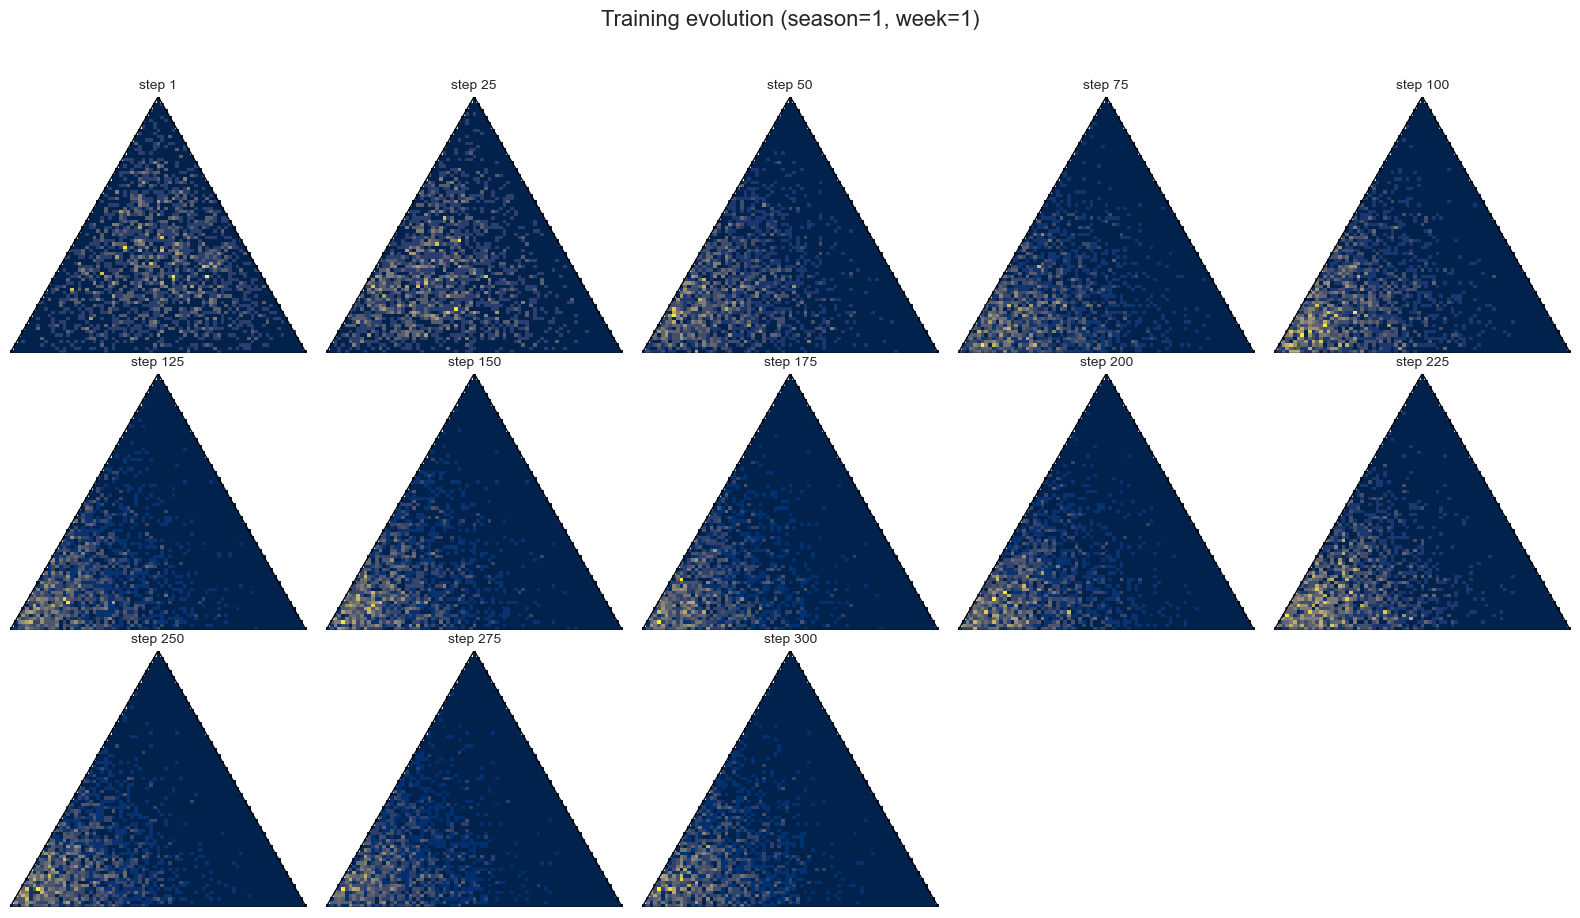

In [178]:
# === Visualization: training trajectory of posterior density toward final placement ===
import numpy as np
import matplotlib.pyplot as plt
import torch

# ---- helpers for triangle projection ----
_SQRT3 = np.sqrt(3.0)

def _bary_to_xy(a, b, c):
    x = b + 0.5 * c
    y = (_SQRT3 / 2.0) * c
    return x, y


def _mask_triangle(X, Y):
    return (Y < 0) | (Y > _SQRT3 / 2.0) | (X < Y / _SQRT3) | (X > 1 - Y / _SQRT3)


# ---- final three selection (from panel) ----
def get_final_three(panel, season):
    alive = panel[(panel["season"] == season) & (panel["alive"] == True)].copy()
    max_week = int(alive["week"].max())
    fin = alive[alive["week"] == max_week].copy()
    if fin.empty:
        raise ValueError("No final week alive rows found for season")
    # if placement column exists, use it (smaller = better)
    if "placement" in fin.columns:
        fin = fin.sort_values("placement")
    else:
        # fallback: pick top by j_metric
        fin = fin.sort_values("j_metric", ascending=False)
    top3 = fin["celebrity_name"].head(3).tolist()
    if len(top3) < 3:
        raise ValueError("Final week has <3 alive contestants")
    return top3


# ---- compute q_hat for a week from current model params ----
def q_for_week_from_model(panel, pooled_fit, model, season, week):
    g = panel[(panel["season"] == season) & (panel["week"] == week) & (panel["alive"] == True)].copy()
    if g.empty:
        raise ValueError("No alive rows for given season/week")
    g = build_features_for_rows(g, pooled_fit)
    X = g[pooled_fit["X_cols"]].to_numpy(dtype=np.float32)

    beta = model.beta.detach().cpu().numpy()
    bias = float(model.bias.detach().cpu().numpy())

    logits = bias + X @ beta

    # add u_hat using embedding, unseen -> 0
    cs_idx = g["cs_idx"].to_numpy(dtype=int)
    u = model.u.weight.detach().cpu().numpy().squeeze(-1)
    add_u = np.zeros(len(g), dtype=np.float32)
    mask = cs_idx >= 0
    add_u[mask] = u[cs_idx[mask]]
    logits = logits + add_u

    z = logits - logits.max()
    q = np.exp(z)
    q = q / q.sum()
    return g, q


# ---- posterior density for final three (importance sampling) ----
def posterior_density_triangle(g, q_mean, final_three, *, kappa=30.0, B=2500, tau_like=0.15, bins=80):
    alive_names = g["celebrity_name"].tolist()
    alive_idx = {c: i for i, c in enumerate(alive_names)}
    f_idx = [alive_idx[c] for c in final_three]

    # elim position (if any)
    if g["elim_this_week_end"].sum() == 1:
        elim_name = g.loc[g["elim_this_week_end"], "celebrity_name"].iloc[0]
        elim_pos = int(np.where(g["celebrity_name"].to_numpy() == elim_name)[0][0])
    else:
        elim_pos = None

    q = np.asarray(q_mean, dtype=float)
    alpha = np.maximum(kappa * q, 1e-8)

    rng = np.random.default_rng(123)
    p_samps = rng.dirichlet(alpha, size=B)

    # weights from softmin elimination likelihood
    if elim_pos is not None:
        j = g["j_metric"].to_numpy()
        cost = j[None, :] + p_samps
        z = -cost / tau_like
        z = z - z.max(axis=1, keepdims=True)
        log_denom = np.log(np.exp(z).sum(axis=1))
        logp_elim = z[:, elim_pos] - log_denom
        w = np.exp(logp_elim - logp_elim.max())
        w = w / w.sum()
    else:
        w = np.ones(B) / B

    # project to triangle using final three and renormalize
    pf = p_samps[:, f_idx]
    pf = pf / pf.sum(axis=1, keepdims=True)

    x = pf[:, 1] + 0.5 * pf[:, 2]
    y = (_SQRT3 / 2.0) * pf[:, 2]

    xbins = np.linspace(0, 1, bins)
    ybins = np.linspace(0, _SQRT3 / 2.0, bins)
    H, _, _ = np.histogram2d(x, y, bins=[xbins, ybins], weights=w, density=False)
    Xc, Yc = np.meshgrid(0.5 * (xbins[1:] + xbins[:-1]), 0.5 * (ybins[1:] + ybins[:-1]), indexing="ij")
    H[_mask_triangle(Xc, Yc)] = np.nan
    if np.nanmax(H) > 0:
        H = H / np.nanmax(H)
    return H.T


# ---- train with snapshots ----
def train_with_snapshots(*, tau, l2_beta, l2_u, lr, n_steps, batch_size,
                         panel, pooled_fit, season_vis, week_vis, snap_every=20):
    model = PooledElimModel(n_cs=n_cs, p=len(X_cols))
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    n_weeks = len(X_list)
    idx_all = np.arange(n_weeks)

    snapshots = []
    steps = []

    def _minibatch_loss(batch_ids):
        nll = 0.0
        for k in batch_ids:
            X = X_list[k]
            J = J_list[k]
            cs_idx = cs_list[k]
            elim_pos = elim_pos_list[k]
            eta = model.forward_eta(X, cs_idx)
            q = torch.softmax(eta, dim=0)
            C = J + q
            logp = torch.log_softmax(-C / tau, dim=0)
            nll = nll - logp[elim_pos]
        nll = nll / max(1, len(batch_ids))
        reg = l2_beta * torch.mean(model.beta**2) + l2_u * torch.mean(model.u.weight.squeeze(-1)**2)
        return nll + reg

    for step in range(1, n_steps + 1):
        batch_ids = np.random.choice(idx_all, size=min(batch_size, n_weeks), replace=False)
        opt.zero_grad()
        loss = _minibatch_loss(batch_ids)
        loss.backward()
        opt.step()

        if step == 1 or step % snap_every == 0 or step == n_steps:
            g, q = q_for_week_from_model(panel, pooled_fit, model, season_vis, week_vis)
            snapshots.append((g, q))
            steps.append(step)

    return model, steps, snapshots


# ---- main: configure and draw ----
# pick a season and week to visualize
season_vis = int(panel["season"].min())
week_vis = int(panel[(panel["season"] == season_vis) & (panel["alive"] == True)]["week"].min())
final_three = get_final_three(panel, season_vis)

# training hyperparams (use the same as your pooled run)
model_tmp, steps, snaps = train_with_snapshots(
    tau=tau, l2_beta=l2_beta, l2_u=l2_u, lr=lr, n_steps=300, batch_size=batch_size,
    panel=panel, pooled_fit=pooled_fit, season_vis=season_vis, week_vis=week_vis, snap_every=25
)

# compute density frames
densities = []
for g, q in snaps:
    H = posterior_density_triangle(g, q, final_three, kappa=kappa, B=2000, tau_like=tau, bins=80)
    densities.append(H)

# plot frames
n = len(densities)
cols = min(5, n)
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.0 * rows))
if rows == 1 and cols == 1:
    axes = np.array([[axes]])
elif rows == 1:
    axes = np.array([axes])
elif cols == 1:
    axes = np.array([[ax] for ax in axes])

for ax, H, st in zip(axes.ravel(), densities, steps):
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.imshow(H, extent=(0, 1, 0, _SQRT3 / 2.0), origin="lower", cmap="cividis", vmin=0, vmax=1)
    ax.plot([0, 1], [0, 0], color="black", lw=1)
    ax.plot([0, 0.5], [0, _SQRT3 / 2.0], color="black", lw=1)
    ax.plot([1, 0.5], [0, _SQRT3 / 2.0], color="black", lw=1)
    ax.set_title("step %d" % st, fontsize=10)

# turn off any extra axes
for j in range(len(densities), rows * cols):
    axes.ravel()[j].set_axis_off()

plt.suptitle("Training evolution (season=%d, week=%d)" % (season_vis, week_vis), y=1.02)
plt.tight_layout()
plt.show()


In [179]:
import numpy as np

def _ess(w):
    # effective sample size
    w = np.asarray(w, float)
    w = w / (w.sum() + 1e-12)
    return 1.0 / (np.sum(w*w) + 1e-12)

def posterior_density_triangle(
    g, q_mean, final_three, *,
    kappa=30.0, B=20000, tau_like=0.15,
    bins=55, smooth_sigma=1.2,
    seed=123
):
    """
    Returns
      H : (bins-1, bins-1) density image on triangle (masked outside) in [0,1] (NOT per-frame max-normalized)
      diag : dict with ESS, sum_pf stats, etc.
    """
    alive_names = g["celebrity_name"].tolist()
    alive_idx = {c: i for i, c in enumerate(alive_names)}
    f_idx = [alive_idx[c] for c in final_three]

    # elim position (if any)
    if g["elim_this_week_end"].sum() == 1:
        elim_name = g.loc[g["elim_this_week_end"], "celebrity_name"].iloc[0]
        elim_pos = int(np.where(g["celebrity_name"].to_numpy() == elim_name)[0][0])
    else:
        elim_pos = None

    q = np.asarray(q_mean, dtype=float)
    alpha = np.maximum(kappa * q, 1e-10)

    rng = np.random.default_rng(seed)
    p_samps = rng.dirichlet(alpha, size=B)

    # weights from softmin elimination likelihood
    if elim_pos is not None:
        j = g["j_metric"].to_numpy()
        cost = j[None, :] + p_samps
        z = -cost / tau_like
        z = z - z.max(axis=1, keepdims=True)
        log_denom = np.log(np.exp(z).sum(axis=1) + 1e-12)
        logp_elim = z[:, elim_pos] - log_denom
        # stable weights
        w = np.exp(logp_elim - np.max(logp_elim))
        w = w / (w.sum() + 1e-12)
    else:
        w = np.ones(B) / B

    ess = _ess(w)

    # project to triangle using final three and renormalize
    pf = p_samps[:, f_idx]
    sum_pf = pf.sum(axis=1)  # important diagnostic!
    pf = pf / (sum_pf[:, None] + 1e-12)

    x = pf[:, 1] + 0.5 * pf[:, 2]
    y = (_SQRT3 / 2.0) * pf[:, 2]

    # histogram (weighted counts)
    xbins = np.linspace(0, 1, bins)
    ybins = np.linspace(0, _SQRT3 / 2.0, bins)
    H, _, _ = np.histogram2d(x, y, bins=[xbins, ybins], weights=w, density=False)

    # mask outside triangle
    Xc, Yc = np.meshgrid(
        0.5 * (xbins[1:] + xbins[:-1]),
        0.5 * (ybins[1:] + ybins[:-1]),
        indexing="ij"
    )
    H = H.T  # to match imshow with origin='lower'
    H[_mask_triangle(Xc.T, Yc.T)] = np.nan

    # ---- smooth (kill "starfield") ----
    # Try scipy if available, else simple 3x3 blur fallback
    try:
        from scipy.ndimage import gaussian_filter
        H2 = np.nan_to_num(H, nan=0.0)
        Hs = gaussian_filter(H2, sigma=smooth_sigma)
        # keep mask
        Hs[np.isnan(H)] = np.nan
        H = Hs
    except Exception:
        H2 = np.nan_to_num(H, nan=0.0)
        # simple blur kernel
        K = np.array([[1,2,1],[2,4,2],[1,2,1]], float)
        K = K / K.sum()
        Hp = np.pad(H2, 1, mode="edge")
        out = np.zeros_like(H2)
        for i in range(out.shape[0]):
            for j in range(out.shape[1]):
                out[i,j] = np.sum(Hp[i:i+3, j:j+3] * K)
        out[np.isnan(H)] = np.nan
        H = out

    # log-compress so low-density structure is visible (prevents "all black")
    H = np.log1p(H)

    diag = dict(
        ESS=float(ess),
        B=int(B),
        sum_pf_mean=float(np.mean(sum_pf)),
        sum_pf_p10=float(np.quantile(sum_pf, 0.10)),
        sum_pf_p50=float(np.quantile(sum_pf, 0.50)),
        sum_pf_p90=float(np.quantile(sum_pf, 0.90)),
        elim_pos=None if elim_pos is None else int(elim_pos),
    )
    return H, diag


In [180]:
alive = panel[(panel["season"]==season_vis) & (panel["alive"]==True)].copy()
weeks = sorted(alive["week"].unique().tolist())

week_frames = []
week_ids = []
week_diags = []
week_means_xy = []

for wk in weeks:
    g = pooled_q_for_week(panel, pooled_fit, season=season_vis, week=wk).copy()
    names = set(g["celebrity_name"].tolist())
    if not all(n in names for n in final_three):
        continue

    q = g["q_hat"].to_numpy()

    H, diag = posterior_density_triangle(
        g, q, final_three,
        kappa=kappa, B=20000, tau_like=tau,
        bins=55, smooth_sigma=1.2
    )
    week_frames.append(H)
    week_ids.append(wk)
    week_diags.append(diag)

    # posterior mean of conditional pf under weights (approx):
    # We can approximate by reusing the prior mean q restricted to final three (stable for display)
    # (If you want the true posterior mean, compute it from weighted samples inside posterior_density_triangle.)
    # Here use q-based proxy:
    alive_names = g["celebrity_name"].tolist()
    alive_idx = {c:i for i,c in enumerate(alive_names)}
    f_idx = [alive_idx[c] for c in final_three]
    qf = q[f_idx]
    qf = qf / (qf.sum() + 1e-12)
    mx, my = _bary_to_xy(qf[0], qf[1], qf[2])
    week_means_xy.append((mx, my))

if len(week_frames) == 0:
    raise ValueError("No weeks found where final three are all alive.")


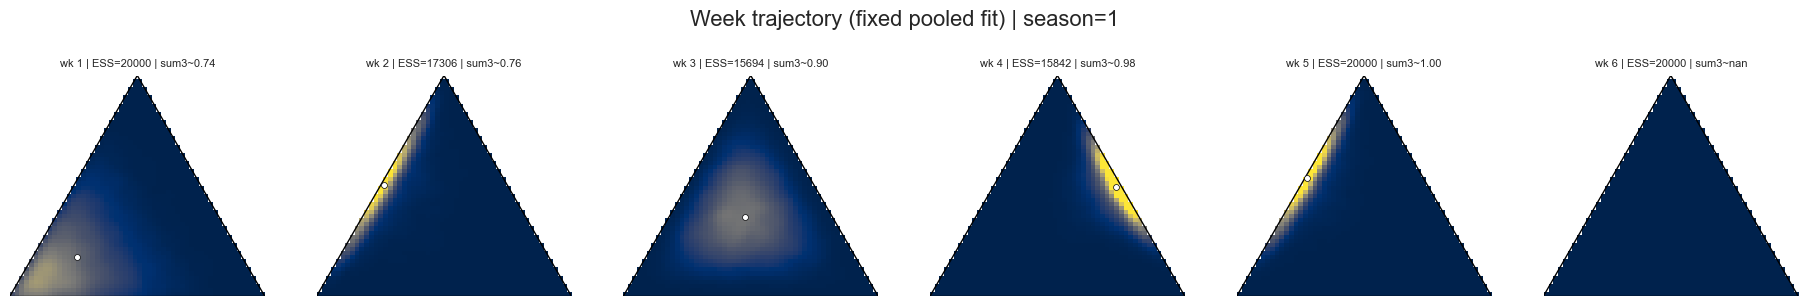

In [181]:
# --- global normalization for comparability ---
vals = np.concatenate([np.ravel(H[np.isfinite(H)]) for H in week_frames])
vmin = np.quantile(vals, 0.05)
vmax = np.quantile(vals, 0.995)

n = len(week_frames)
cols = min(6, n)
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(3.1 * cols, 3.0 * rows))

# normalize axes shape
if rows == 1 and cols == 1:
    axes = np.array([[axes]])
elif rows == 1:
    axes = np.array([axes])
elif cols == 1:
    axes = np.array([[ax] for ax in axes])

for ax, H, wk, diag, (mx,my) in zip(axes.ravel(), week_frames, week_ids, week_diags, week_means_xy):
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.imshow(H, extent=(0, 1, 0, _SQRT3 / 2.0), origin="lower",
              cmap="cividis", vmin=vmin, vmax=vmax)

    # triangle border
    ax.plot([0, 1], [0, 0], color="black", lw=1)
    ax.plot([0, 0.5], [0, _SQRT3 / 2.0], color="black", lw=1)
    ax.plot([1, 0.5], [0, _SQRT3 / 2.0], color="black", lw=1)

    # trajectory point (proxy mean)
    ax.scatter([mx], [my], s=18, c="white", edgecolors="black", linewidths=0.5, zorder=5)

    # informative title
    ax.set_title(f"wk {wk} | ESS={diag['ESS']:.0f} | sum3~{diag['sum_pf_p50']:.2f}", fontsize=8)

# turn off any extra axes
for j in range(len(week_frames), rows * cols):
    axes.ravel()[j].set_axis_off()

plt.suptitle(f"Week trajectory (fixed pooled fit) | season={season_vis}", y=1.02)
plt.tight_layout()
plt.show()


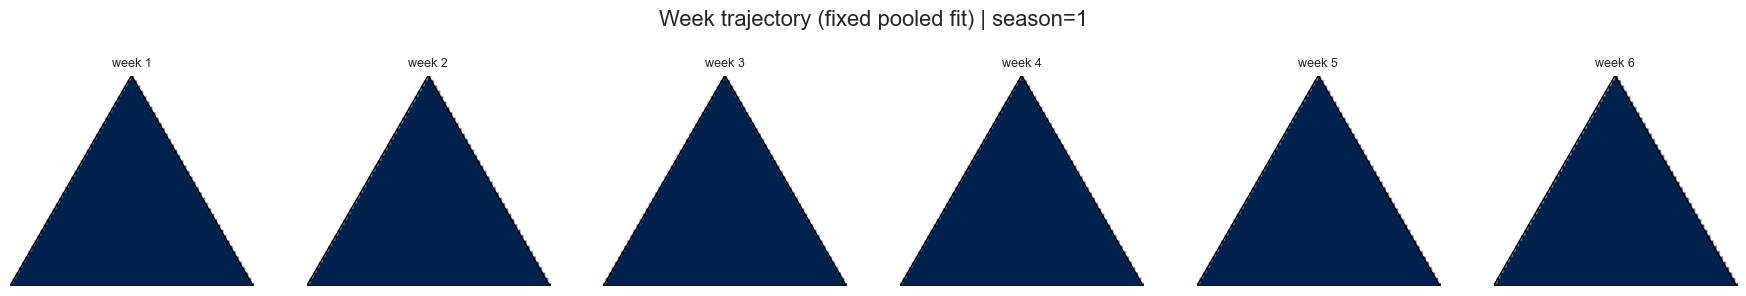

In [182]:
# === Visualization: week trajectory with fixed trained parameters ===
# This uses pooled_fit (beta_hat, bias_hat, u_hat) fixed after training.

# pick a season to visualize (same as above, or override)
season_vis = int(panel["season"].min())
final_three = get_final_three(panel, season_vis)

# collect weeks where all final_three are in alive set
alive = panel[(panel["season"]==season_vis) & (panel["alive"]==True)].copy()
weeks = sorted(alive["week"].unique().tolist())

week_frames = []
week_ids = []
for wk in weeks:
    g = pooled_q_for_week(panel, pooled_fit, season=season_vis, week=wk).copy()
    names = set(g["celebrity_name"].tolist())
    # only visualize weeks where final three are all alive
    if not all(n in names for n in final_three):
        continue
    q = g["q_hat"].to_numpy()
    H, _ = posterior_density_triangle(g, q, final_three, kappa=kappa, B=2000, tau_like=tau, bins=80)
    week_frames.append(H)
    week_ids.append(wk)

if len(week_frames) == 0:
    raise ValueError("No weeks found where final three are all alive.")

# plot frames in chronological order
n = len(week_frames)
cols = min(6, n)
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(3.0 * cols, 2.9 * rows))
if rows == 1 and cols == 1:
    axes = np.array([[axes]])
elif rows == 1:
    axes = np.array([axes])
elif cols == 1:
    axes = np.array([[ax] for ax in axes])

for ax, H, wk in zip(axes.ravel(), week_frames, week_ids):
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.imshow(H, extent=(0, 1, 0, _SQRT3 / 2.0), origin="lower", cmap="cividis", vmin=0, vmax=1)
    ax.plot([0, 1], [0, 0], color="black", lw=1)
    ax.plot([0, 0.5], [0, _SQRT3 / 2.0], color="black", lw=1)
    ax.plot([1, 0.5], [0, _SQRT3 / 2.0], color="black", lw=1)
    ax.set_title("week %d" % wk, fontsize=9)

# turn off any extra axes
for j in range(len(week_frames), rows * cols):
    axes.ravel()[j].set_axis_off()

plt.suptitle("Week trajectory (fixed pooled fit) | season=%d" % season_vis, y=1.02)
plt.tight_layout()
plt.show()


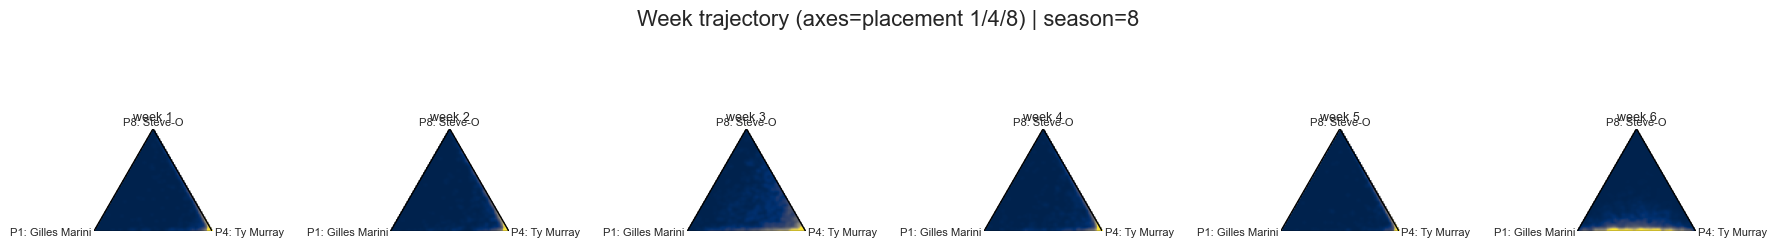

In [183]:
# === Visualization: week trajectory using placement {1,4,8} axes ===
# Keep fixed pooled_fit; choose a season with many weeks and clear placements.

# pick a season: maximize weeks among seasons that have placement and 1/4/8 present
if "placement" not in panel.columns:
    # derive placement from elimination order within each season
    # earlier elimination => worse placement (larger number), final survivors => top placement
    alive_all = panel[panel["alive"]==True].copy()
    # elimination week per contestant (if eliminated); final week for survivors
    elim_week = (alive_all[alive_all["elim_this_week_end"]==True]
                 .groupby(["season","celebrity_name"])["week"].min().rename("elim_week"))
    max_week = alive_all.groupby("season")["week"].max().rename("max_week")

    tmp = alive_all[["season","celebrity_name"]].drop_duplicates().set_index(["season","celebrity_name"])
    tmp = tmp.join(elim_week, how="left")
    tmp = tmp.join(max_week, on="season", how="left")
    # survivors get elim_week = max_week + 1 (so they rank highest)
    tmp["elim_week"] = tmp["elim_week"].fillna(tmp["max_week"] + 1)

    # placement: sort by elim_week ascending within season (earlier out = lower rank)
    tmp = tmp.reset_index()
    tmp["placement"] = tmp.groupby("season")["elim_week"].rank(method="first", ascending=False).astype(int)
    # Note: larger placement number = worse; placement=1 is winner

    panel = panel.merge(tmp[["season","celebrity_name","placement"]],
                        on=["season","celebrity_name"], how="left")

# now placement exists

alive_all = panel[panel["alive"]==True].copy()

# seasons with placement 1/4/8 available in final season roster
cand = []
for s, g in alive_all.groupby("season"):
    # placement might be static; check at any week (use season-level unique)
    pl = g[["celebrity_name","placement"]].dropna().drop_duplicates()
    if set([1,4,8]).issubset(set(pl["placement"].astype(int).tolist())):
        weeks = g["week"].nunique()
        cand.append((s, weeks))

if not cand:
    raise ValueError("No season found with placements {1,4,8} present.")

season_vis = int(sorted(cand, key=lambda x: x[1], reverse=True)[0][0])

# choose axes by placement=1,4,8
pl_map = (alive_all[alive_all["season"]==season_vis]
          [["celebrity_name","placement"]]
          .dropna().drop_duplicates())

axis_names = [
    pl_map.loc[pl_map["placement"].astype(int)==1, "celebrity_name"].iloc[0],
    pl_map.loc[pl_map["placement"].astype(int)==4, "celebrity_name"].iloc[0],
    pl_map.loc[pl_map["placement"].astype(int)==8, "celebrity_name"].iloc[0]
]

# define trajectory weeks: from week 1 until before placement=8 eliminated
# find elimination week for placement=8 contestant
elim8 = (panel[(panel["season"]==season_vis) & (panel["celebrity_name"]==axis_names[2]) &
               (panel["elim_this_week_end"]==True)])["week"]

if elim8.empty:
    # if no elimination flag found (e.g., missing), fall back to max week in season
    last_week = int(alive_all[alive_all["season"]==season_vis]["week"].max())
else:
    last_week = int(elim8.iloc[0])

# collect weeks 1..last_week (inclusive), only if all axis contestants alive
weeks = list(range(1, last_week + 1))

week_frames = []
week_ids = []
for wk in weeks:
    g = pooled_q_for_week(panel, pooled_fit, season=season_vis, week=wk).copy()
    names = set(g["celebrity_name"].tolist())
    if not all(n in names for n in axis_names):
        continue
    q = g["q_hat"].to_numpy()
    H, _ = posterior_density_triangle(g, q, axis_names, kappa=kappa, B=2000, tau_like=tau, bins=80)
    week_frames.append(H)
    week_ids.append(wk)

if len(week_frames) == 0:
    raise ValueError("No weeks found where placement=1,4,8 are all alive before elimination.")

# --- global normalization for comparability ---
vals = np.concatenate([np.ravel(H[np.isfinite(H)]) for H in week_frames])
vmin = np.quantile(vals, 0.05)
vmax = np.quantile(vals, 0.995)

# plot frames in chronological order
n = len(week_frames)
cols = min(6, n)
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(3.0 * cols, 2.9 * rows))
if rows == 1 and cols == 1:
    axes = np.array([[axes]])
elif rows == 1:
    axes = np.array([axes])
elif cols == 1:
    axes = np.array([[ax] for ax in axes])

for ax, H, wk in zip(axes.ravel(), week_frames, week_ids):
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.imshow(H, extent=(0, 1, 0, _SQRT3 / 2.0), origin="lower", cmap="cividis", vmin=vmin, vmax=vmax)
    ax.plot([0, 1], [0, 0], color="black", lw=1)
    ax.plot([0, 0.5], [0, _SQRT3 / 2.0], color="black", lw=1)
    ax.plot([1, 0.5], [0, _SQRT3 / 2.0], color="black", lw=1)
    # axis labels: A/B/C correspond to placement 1/4/8
    ax.text(-0.02, -0.03, "P1: %s" % axis_names[0], fontsize=8, ha="right")
    ax.text(1.02, -0.03, "P4: %s" % axis_names[1], fontsize=8, ha="left")
    ax.text(0.5, _SQRT3/2.0 + 0.03, "P8: %s" % axis_names[2], fontsize=8, ha="center")
    ax.set_title("week %d" % wk, fontsize=9)

# turn off any extra axes
for j in range(len(week_frames), rows * cols):
    axes.ravel()[j].set_axis_off()

plt.suptitle("Week trajectory (axes=placement 1/4/8) | season=%d" % season_vis, y=1.02)
plt.tight_layout()
plt.show()


In [184]:
# (Optional) Evaluate elimination consistency on training weeks using posterior mean:
# Predict eliminated as argmin(j_metric + p_mean) among alive.
post_all = []
for (s,wk) in train_weeks[["season","week"]].values.tolist():
    res = infer_week_posterior_pooled(panel, pooled_fit, int(s), int(wk), kappa=kappa, B=B, tau_like=tau)
    if res is not None:
        post_all.append(res)

post = pd.concat(post_all, ignore_index=True)
truth = panel[(panel["alive"]==True) & (panel["elim_this_week_end"]==True)][["season","week","celebrity_name"]].rename(
    columns={"celebrity_name":"elim_true"}
)
truth_cnt = truth.groupby(["season","week"]).size().rename("n_elim").reset_index()

eval_df = post.merge(truth, on=["season","week"], how="left").merge(truth_cnt, on=["season","week"], how="left")
eval_df = eval_df[eval_df["n_elim"].eq(1)].copy()

eval_df["C_hat"] = eval_df["j_metric"] + eval_df["p_mean"]
pred = eval_df.loc[eval_df.groupby(["season","week"])["C_hat"].idxmin(),
                   ["season","week","celebrity_name","elim_true"]]
pred["correct"] = pred["celebrity_name"].eq(pred["elim_true"])

acc = pred["correct"].mean()
acc, pred.head()


(0.9587155963302753,
     season  week     celebrity_name          elim_true  correct
 5        1     2      Trista Sutter      Trista Sutter     True
 6        1     3  Evander Holyfield  Evander Holyfield     True
 14       1     4      Rachel Hunter      Rachel Hunter     True
 19       2     1        Kenny Mayne        Kenny Mayne     True
 32       2     2       Tatum O'Neal       Tatum O'Neal     True)

## 5) Evaluation + Visualization (Seaborn)

We evaluate only **non-final weeks with exactly one elimination** (the same supervision signal used in training). We report:

- Elimination accuracy (argmin of $\hat C=j+\hat p$)
- Bottom-2 coverage
- Negative log-likelihood (softmin likelihood)
- Stratified results by era / season
- Uncertainty diagnostics using CI width


In [185]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", font_scale=1.1)

# --- build evaluation set: non-final single-elim weeks ---
truth = panel[panel["elim_this_week_end"]][["season","week","celebrity_name"]].rename(columns={"celebrity_name":"elim_true"})
elim_counts = truth.groupby(["season","week"]).size().rename("n_elim").reset_index()

eval_long = (post.merge(truth, on=["season","week"], how="left")
                .merge(elim_counts, on=["season","week"], how="left")
                .merge(panel[["season","week","max_week"]].drop_duplicates(), on=["season","week"], how="left"))

eval_long["n_elim"] = eval_long["n_elim"].fillna(0).astype(int)
eval_long["is_final_week"] = eval_long["week"].astype(int).eq(eval_long["max_week"].astype(int))

eval_long = eval_long[(eval_long["n_elim"].eq(1)) & (~eval_long["is_final_week"])].copy()
print("Eval rows:", eval_long.shape, "Eval weeks:", eval_long[["season","week"]].drop_duplicates().shape[0])
eval_long.head()


Eval rows: (1860, 16) Eval weeks: 218


,season,week,celebrity_name,era,j_metric,elim_this_week_end,p_mean,q_mean,p_lo,p_hi,ci_width,has_ci,elim_true,n_elim,max_week,is_final_week
0,1,2,Evander Holyfield,rank,0.000001,False,0.167398,0.147250,1.944012e-02,0.416893,0.397453,True,Trista Sutter,1,6,False
1,1,2,Joey McIntyre,rank,0.003585,False,0.370611,0.374760,1.179240e-01,0.659133,0.541209,True,Trista Sutter,1,6,False
2,1,2,John O'Hurley,rank,0.877190,False,0.010663,0.010126,1.795569e-17,0.124136,0.124136,True,Trista Sutter,1,6,False
3,1,2,Kelly Monaco,rank,0.000024,False,0.362084,0.359992,1.204098e-01,0.663715,0.543306,True,Trista Sutter,1,6,False
4,1,2,Rachel Hunter,rank,0.118715,False,0.061858,0.061363,2.365141e-04,0.242842,0.242606,True,Trista Sutter,1,6,False


In [186]:

def softmin_probs(C, tau=0.15):
    x = -C / tau
    x = x - np.max(x)
    p = np.exp(x)
    return p / p.sum()

# --- week-level metrics ---
rows = []
for (s,w), g in eval_long.groupby(["season","week"]):
    g = g.copy()
    elim_true = g["elim_true"].iloc[0]
    names = g["celebrity_name"].tolist()

    j = g["j_metric"].to_numpy()
    p = g["p_mean"].to_numpy()
    q = g["q_mean"].to_numpy()

    C_model = j + p
    C_jonly = j
    C_qonly = q

    pred_model = names[int(np.argmin(C_model))]
    pred_jonly = names[int(np.argmin(C_jonly))]
    pred_qonly = names[int(np.argmin(C_qonly))]

    bottom2_model = {names[i] for i in np.argsort(C_model)[:2]}
    bottom2_jonly = {names[i] for i in np.argsort(C_jonly)[:2]}
    bottom2_qonly = {names[i] for i in np.argsort(C_qonly)[:2]}

    tau_like = tau
    pr_model = softmin_probs(C_model, tau=tau_like)[names.index(elim_true)]
    pr_jonly = softmin_probs(C_jonly, tau=tau_like)[names.index(elim_true)]
    pr_qonly = softmin_probs(C_qonly, tau=tau_like)[names.index(elim_true)]

    ci_width_mean = g["ci_width"].dropna().mean()

    rows.append({
        "season": s, "week": w, "era": g["era"].iloc[0],
        "elim_true": elim_true,
        "pred_model": pred_model, "pred_jonly": pred_jonly, "pred_qonly": pred_qonly,
        "acc_model": pred_model == elim_true,
        "acc_jonly": pred_jonly == elim_true,
        "acc_qonly": pred_qonly == elim_true,
        "bottom2_model": elim_true in bottom2_model,
        "bottom2_jonly": elim_true in bottom2_jonly,
        "bottom2_qonly": elim_true in bottom2_qonly,
        "nll_model": -np.log(max(pr_model, 1e-12)),
        "nll_jonly": -np.log(max(pr_jonly, 1e-12)),
        "nll_qonly": -np.log(max(pr_qonly, 1e-12)),
        "ci_width_mean": ci_width_mean,
    })

week_metrics = pd.DataFrame(rows)
week_metrics.head()


,season,week,era,elim_true,pred_model,pred_jonly,pred_qonly,acc_model,acc_jonly,acc_qonly,bottom2_model,bottom2_jonly,bottom2_qonly,nll_model,nll_jonly,nll_qonly,ci_width_mean
0,1,2,rank,Trista Sutter,Trista Sutter,Evander Holyfield,John O'Hurley,True,False,False,True,False,True,0.105068,1.399424,1.373662,0.327776
1,1,3,rank,Evander Holyfield,Evander Holyfield,Evander Holyfield,Rachel Hunter,True,True,False,True,True,True,0.022080,1.171247,2.544436,0.351626
2,1,4,rank,Rachel Hunter,Rachel Hunter,Joey McIntyre,Kelly Monaco,True,False,False,True,False,True,0.043015,5.983152,0.901934,0.275367
3,2,1,rank,Kenny Mayne,Kenny Mayne,Master P,Drew Lachey,True,False,False,True,True,True,0.757851,2.040826,1.537881,0.274479
4,2,2,rank,Tatum O'Neal,Tatum O'Neal,Master P,Stacy Keibler,True,False,False,True,True,True,0.701427,1.957432,1.338124,0.292647


In [187]:

def summarize(df):
    return pd.Series({
        "weeks": len(df),
        "acc_model": df["acc_model"].mean(),
        "acc_jonly": df["acc_jonly"].mean(),
        "acc_qonly": df["acc_qonly"].mean(),
        "bottom2_model": df["bottom2_model"].mean(),
        "bottom2_jonly": df["bottom2_jonly"].mean(),
        "bottom2_qonly": df["bottom2_qonly"].mean(),
        "nll_model": df["nll_model"].mean(),
        "nll_jonly": df["nll_jonly"].mean(),
        "nll_qonly": df["nll_qonly"].mean(),
        "mean_ci_width": df["ci_width_mean"].dropna().mean(),
    })

overall = summarize(week_metrics)
by_era = week_metrics.groupby("era").apply(summarize)
by_season = week_metrics.groupby("season").apply(summarize).sort_index()

print("OVERALL\n", overall, "\n")
print("BY ERA\n", by_era, "\n")
by_season.head(10)


OVERALL
 weeks            218.000000
acc_model          0.958716
acc_jonly          0.389908
acc_qonly          0.266055
bottom2_model      0.963303
bottom2_jonly      0.633028
bottom2_qonly      0.807339
nll_model          0.905372
nll_jonly          2.294543
nll_qonly          1.895466
mean_ci_width      0.305248
dtype: float64 

BY ERA
          weeks  acc_model  acc_jonly  acc_qonly  bottom2_model  bottom2_jonly  \
era                                                                             
percent   44.0   0.977273   0.318182   0.886364       1.000000       0.636364   
rank     174.0   0.954023   0.408046   0.109195       0.954023       0.632184   

         bottom2_qonly  nll_model  nll_jonly  nll_qonly  mean_ci_width  
era                                                                     
percent       1.000000   0.906461   2.068953   1.206137       0.306037  
rank          0.758621   0.905097   2.351589   2.069779       0.305049   



/var/folders/1q/v465hb014m30111mh0rv30rh0000gn/T/ipykernel_44988/1693474516.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_era = week_metrics.groupby("era").apply(summarize)
/var/folders/1q/v465hb014m30111mh0rv30rh0000gn/T/ipykernel_44988/1693474516.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_season = week_metrics.groupby("season").apply(summarize).sort_index()


,weeks,acc_model,acc_jonly,acc_qonly,bottom2_model,bottom2_jonly,bottom2_qonly,nll_model,nll_jonly,nll_qonly,mean_ci_width
season,,,,,,,,,,,
1,3.0,1.0,0.333333,0.000000,1.0,0.333333,1.000000,0.056721,2.851275,1.606678,0.318256
2,7.0,1.0,0.428571,0.000000,1.0,0.857143,0.714286,0.311887,1.593807,2.618125,0.321460
3,6.0,1.0,0.333333,0.000000,1.0,0.500000,0.666667,0.458026,1.617019,2.326034,0.310339
4,8.0,1.0,0.375000,0.000000,1.0,0.500000,0.625000,0.400136,1.501511,2.465765,0.319382
5,9.0,1.0,0.333333,0.000000,1.0,0.666667,0.555556,0.457209,1.710348,2.646112,0.303081
6,7.0,1.0,0.571429,0.142857,1.0,0.571429,0.857143,0.380404,1.458823,2.463972,0.326679
7,6.0,1.0,0.500000,0.166667,1.0,0.666667,1.000000,0.282270,1.493041,2.426141,0.325339
8,8.0,1.0,0.375000,0.125000,1.0,0.625000,0.875000,0.506508,1.633634,2.332330,0.314395
9,5.0,1.0,0.400000,0.000000,1.0,0.400000,0.800000,0.566038,1.972666,2.263261,0.292492


### Plots

Below are seaborn plots you can paste into the paper (with minor styling).

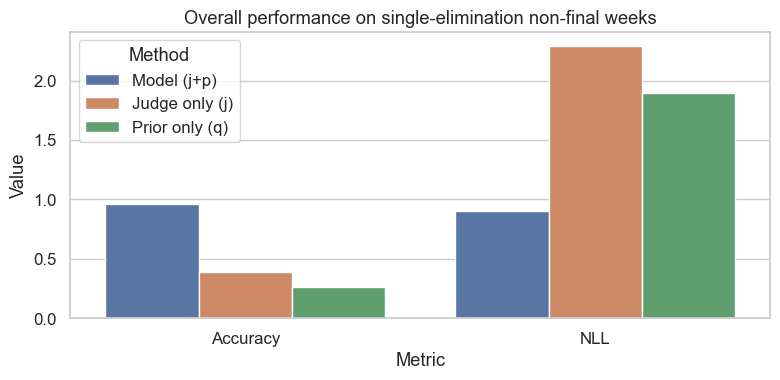

In [188]:

# --- Plot 1: Overall comparison (Accuracy & NLL) ---
plot_df = pd.DataFrame({
    "Metric": ["Accuracy", "Accuracy", "Accuracy", "NLL", "NLL", "NLL"],
    "Method": ["Model (j+p)", "Judge only (j)", "Prior only (q)",
               "Model (j+p)", "Judge only (j)", "Prior only (q)"],
    "Value": [
        week_metrics["acc_model"].mean(),
        week_metrics["acc_jonly"].mean(),
        week_metrics["acc_qonly"].mean(),
        week_metrics["nll_model"].mean(),
        week_metrics["nll_jonly"].mean(),
        week_metrics["nll_qonly"].mean(),
    ]
})

plt.figure(figsize=(8,4))
sns.barplot(data=plot_df, x="Metric", y="Value", hue="Method")
plt.title("Overall performance on single-elimination non-final weeks")
plt.tight_layout()
plt.show()


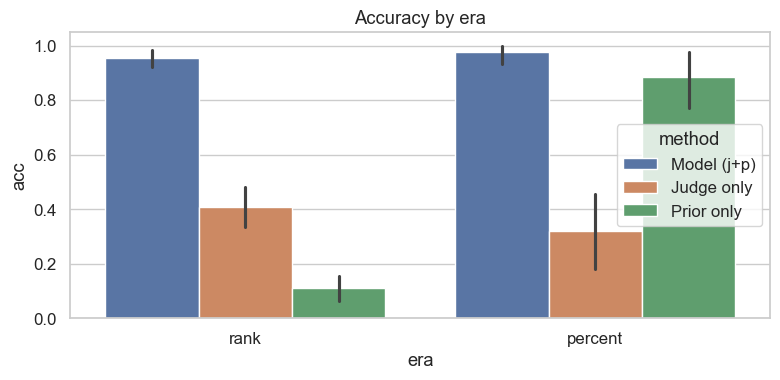

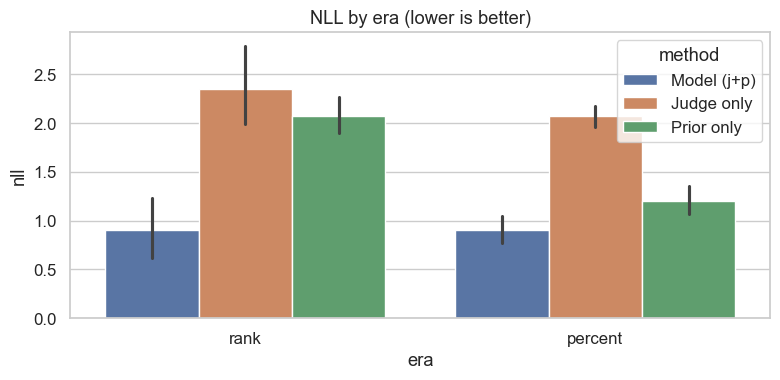

In [189]:

# --- Plot 2: By era (rule segment) ---
melt_acc = week_metrics.melt(id_vars=["era"], value_vars=["acc_model","acc_jonly","acc_qonly"],
                            var_name="method", value_name="acc")
melt_acc["method"] = melt_acc["method"].map({
    "acc_model":"Model (j+p)", "acc_jonly":"Judge only", "acc_qonly":"Prior only"
})

plt.figure(figsize=(8,4))
sns.barplot(data=melt_acc, x="era", y="acc", hue="method")
plt.title("Accuracy by era")
plt.tight_layout()
plt.show()

melt_nll = week_metrics.melt(id_vars=["era"], value_vars=["nll_model","nll_jonly","nll_qonly"],
                            var_name="method", value_name="nll")
melt_nll["method"] = melt_nll["method"].map({
    "nll_model":"Model (j+p)", "nll_jonly":"Judge only", "nll_qonly":"Prior only"
})

plt.figure(figsize=(8,4))
sns.barplot(data=melt_nll, x="era", y="nll", hue="method")
plt.title("NLL by era (lower is better)")
plt.tight_layout()
plt.show()


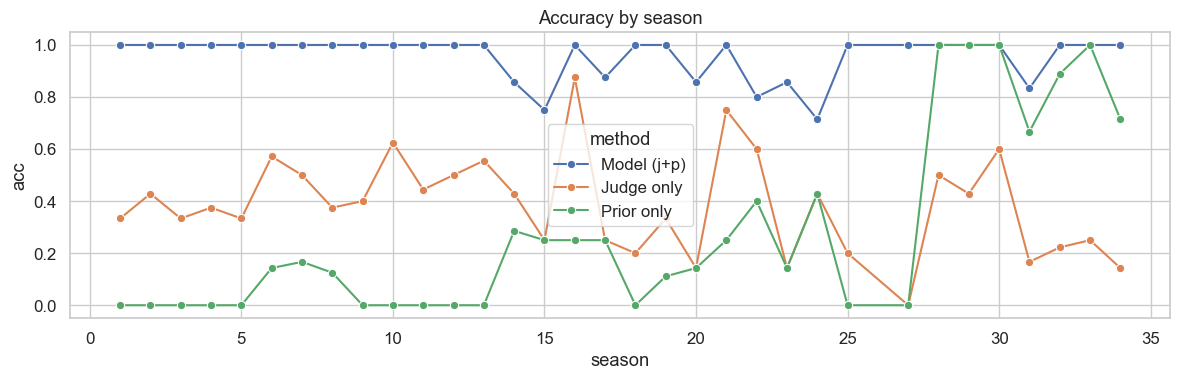

In [190]:

# --- Plot 3: By season line chart ---
season_acc = week_metrics.groupby("season")[["acc_model","acc_jonly","acc_qonly"]].mean().reset_index()
season_acc = season_acc.melt(id_vars="season", var_name="method", value_name="acc")
season_acc["method"] = season_acc["method"].map({
    "acc_model":"Model (j+p)", "acc_jonly":"Judge only", "acc_qonly":"Prior only"
})

plt.figure(figsize=(12,4))
sns.lineplot(data=season_acc, x="season", y="acc", hue="method", marker="o")
plt.title("Accuracy by season")
plt.tight_layout()
plt.show()


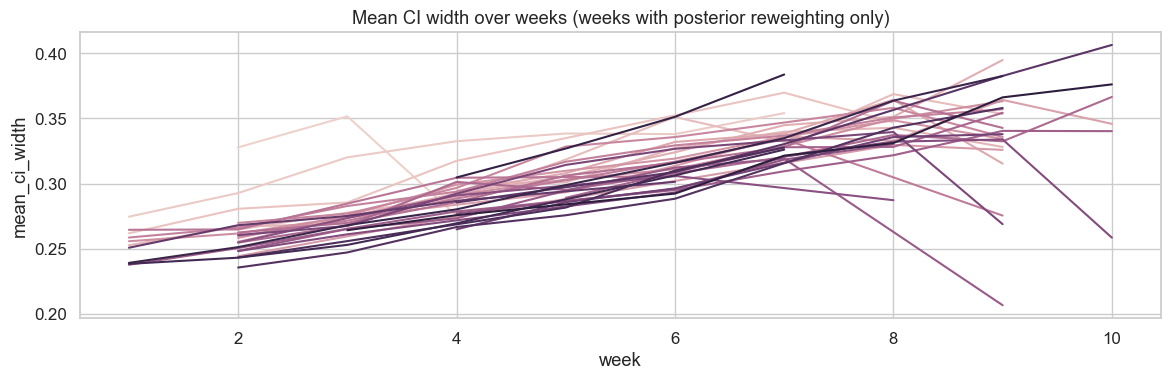

In [191]:

# --- Plot 4: Uncertainty over weeks (CI width) ---
ci_week = (eval_long[eval_long["has_ci"]]
           .groupby(["season","week"])["ci_width"]
           .mean().reset_index(name="mean_ci_width"))

plt.figure(figsize=(12,4))
sns.lineplot(data=ci_week, x="week", y="mean_ci_width", hue="season", legend=False)
plt.title("Mean CI width over weeks (weeks with posterior reweighting only)")
plt.tight_layout()
plt.show()


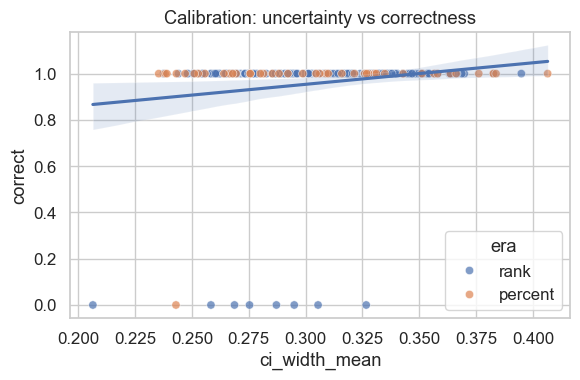

In [192]:

# --- Plot 5: Calibration check (CI width vs correctness) ---
tmp = week_metrics.dropna(subset=["ci_width_mean"]).copy()
tmp["correct"] = tmp["acc_model"].astype(int)

plt.figure(figsize=(6,4))
sns.scatterplot(data=tmp, x="ci_width_mean", y="correct", hue="era", alpha=0.7)
sns.regplot(data=tmp, x="ci_width_mean", y="correct", scatter=False)
plt.title("Calibration: uncertainty vs correctness")
plt.tight_layout()
plt.show()


/var/folders/1q/v465hb014m30111mh0rv30rh0000gn/T/ipykernel_44988/1692495393.py:9: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=exdf, y="celebrity_name", x="p_mean", join=False)


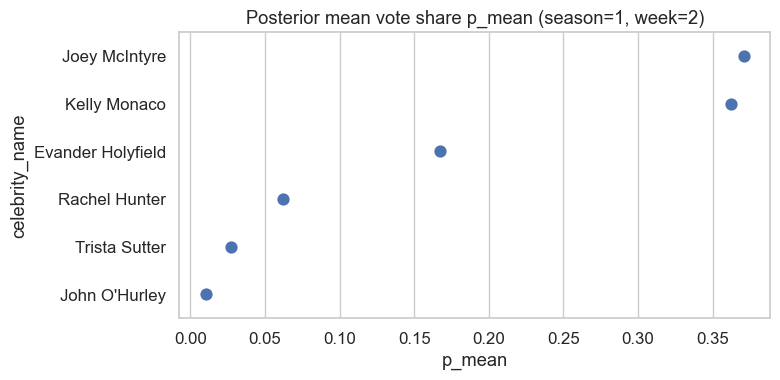

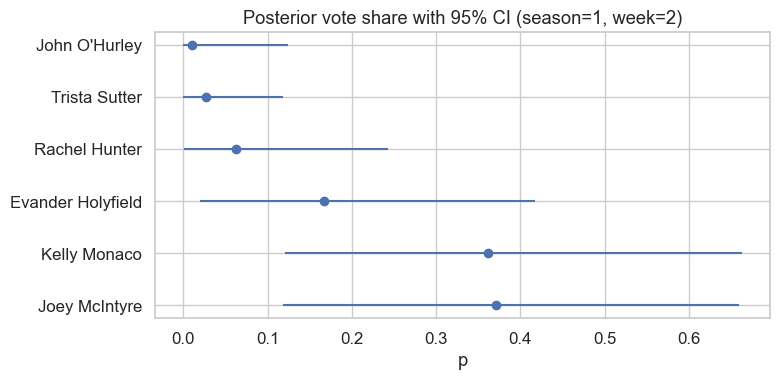

,season,week,celebrity_name,era,j_metric,elim_this_week_end,p_mean,q_mean,p_lo,p_hi,ci_width,has_ci
1,1,2,Joey McIntyre,rank,0.003585,False,0.370611,0.374760,1.179240e-01,0.659133,0.541209,True
3,1,2,Kelly Monaco,rank,0.000024,False,0.362084,0.359992,1.204098e-01,0.663715,0.543306,True
0,1,2,Evander Holyfield,rank,0.000001,False,0.167398,0.147250,1.944012e-02,0.416893,0.397453,True
4,1,2,Rachel Hunter,rank,0.118715,False,0.061858,0.061363,2.365141e-04,0.242842,0.242606,True
5,1,2,Trista Sutter,rank,0.000485,True,0.027386,0.046508,2.076994e-05,0.117965,0.117944,True
2,1,2,John O'Hurley,rank,0.877190,False,0.010663,0.010126,1.795569e-17,0.124136,0.124136,True


In [193]:

# --- Plot 6: A concrete week table (posterior p + CI) ---
ex = post[post["has_ci"]].sort_values(["season","week"]).head(1)[["season","week"]].iloc[0]
s_ex, w_ex = int(ex["season"]), int(ex["week"])

exdf = post[(post["season"]==s_ex) & (post["week"]==w_ex)].copy()
exdf = exdf.sort_values("p_mean", ascending=False)

plt.figure(figsize=(8, max(4, 0.35*len(exdf))))
sns.pointplot(data=exdf, y="celebrity_name", x="p_mean", join=False)
plt.title(f"Posterior mean vote share p_mean (season={s_ex}, week={w_ex})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, max(4, 0.35*len(exdf))))
plt.errorbar(exdf["p_mean"], exdf["celebrity_name"],
             xerr=[exdf["p_mean"]-exdf["p_lo"], exdf["p_hi"]-exdf["p_mean"]],
             fmt="o")
plt.title(f"Posterior vote share with 95% CI (season={s_ex}, week={w_ex})")
plt.xlabel("p")
plt.tight_layout()
plt.show()

exdf.head(20)


### Optional: simple forward-chaining split (train/test)

This is **not** a full re-train per split (which is expensive). It is a quick diagnostic: mark the last K single-elim weeks in each season as test and report metrics. For a proper split, re-train the pooled model using only train weeks, then run inference on test weeks.

In [194]:

K = 2  # last K single-elim weeks per season as test
wm = week_metrics.copy()
wm["is_test"] = False

for s, g in wm.groupby("season"):
    g = g.sort_values("week")
    test_idx = g.tail(K).index
    wm.loc[test_idx, "is_test"] = True

def quick_report(df, name):
    print(name, "weeks=", len(df))
    print("  acc_model:", round(df["acc_model"].mean(),4),
          "acc_jonly:", round(df["acc_jonly"].mean(),4),
          "acc_qonly:", round(df["acc_qonly"].mean(),4))
    print("  nll_model:", round(df["nll_model"].mean(),4),
          "nll_jonly:", round(df["nll_jonly"].mean(),4),
          "nll_qonly:", round(df["nll_qonly"].mean(),4))
    print("  bottom2_model:", round(df["bottom2_model"].mean(),4),
          "bottom2_jonly:", round(df["bottom2_jonly"].mean(),4),
          "bottom2_qonly:", round(df["bottom2_qonly"].mean(),4))

quick_report(wm[~wm["is_test"]], "TRAIN (proxy)")
quick_report(wm[wm["is_test"]], "TEST (proxy)")


TRAIN (proxy) weeks= 152
  acc_model: 0.9803 acc_jonly: 0.3816 acc_qonly: 0.2632
  nll_model: 0.9478 nll_jonly: 2.1865 nll_qonly: 1.5647
  bottom2_model: 0.9868 bottom2_jonly: 0.6184 bottom2_qonly: 0.8421
TEST (proxy) weeks= 66
  acc_model: 0.9091 acc_jonly: 0.4091 acc_qonly: 0.2727
  nll_model: 0.8076 nll_jonly: 2.5434 nll_qonly: 2.6573
  bottom2_model: 0.9091 bottom2_jonly: 0.6667 bottom2_qonly: 0.7273


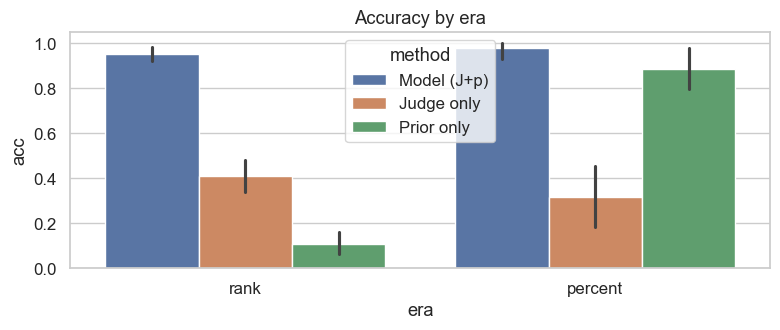

In [195]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

melt_acc = week_metrics.melt(
    id_vars=["era"],
    value_vars=["acc_model","acc_jonly","acc_qonly"],
    var_name="method", value_name="acc"
)
melt_acc["method"] = melt_acc["method"].map({
    "acc_model":"Model (J+p)", "acc_jonly":"Judge only", "acc_qonly":"Prior only"
})

plt.figure(figsize=(8,3.5))
sns.barplot(data=melt_acc, x="era", y="acc", hue="method")
plt.title("Accuracy by era")
plt.tight_layout()
plt.show()


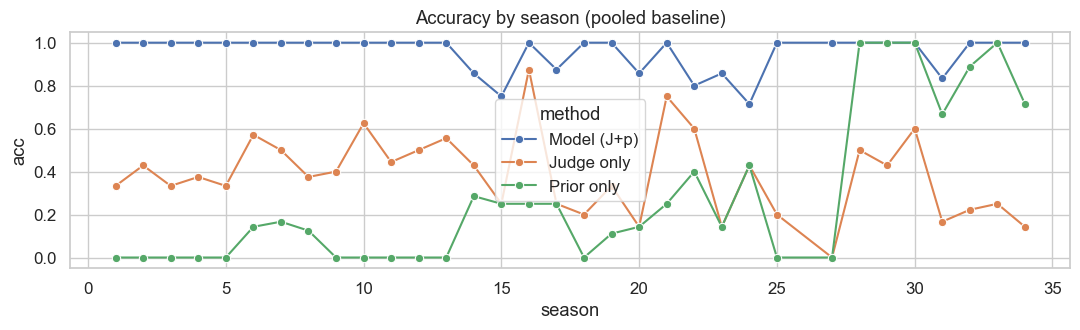

In [196]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

season_acc = week_metrics.groupby("season")[["acc_model","acc_jonly","acc_qonly"]].mean().reset_index()
season_acc = season_acc.melt(id_vars="season", var_name="method", value_name="acc")
season_acc["method"] = season_acc["method"].map({
    "acc_model":"Model (J+p)", "acc_jonly":"Judge only", "acc_qonly":"Prior only"
})

plt.figure(figsize=(11,3.5))
sns.lineplot(data=season_acc, x="season", y="acc", hue="method", marker="o")
plt.title("Accuracy by season (pooled baseline)")
plt.tight_layout()
plt.show()


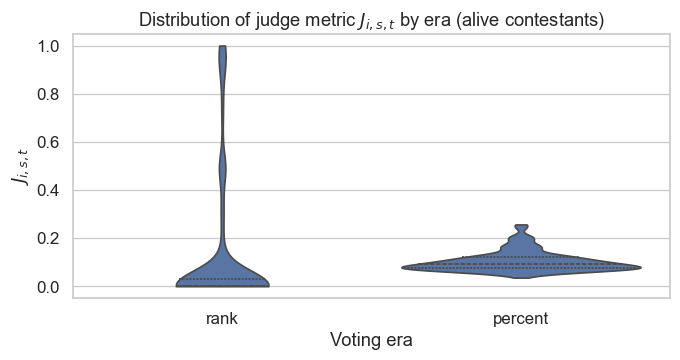

In [197]:
import seaborn as sns
import matplotlib.pyplot as plt

dfJ = panel[panel["alive"]==True][["era","j_metric"]].dropna().copy()

plt.figure(figsize=(7,3.8))
sns.violinplot(data=dfJ, x="era", y="j_metric", inner="quartile", cut=0)
plt.title(r"Distribution of judge metric $J_{i,s,t}$ by era (alive contestants)")
plt.xlabel("Voting era")
plt.ylabel(r"$J_{i,s,t}$")
plt.tight_layout()

# 文件名给你：论文里引用用这个
plt.savefig("fig_J_distribution_by_era.png", dpi=300, bbox_inches="tight")
plt.show()


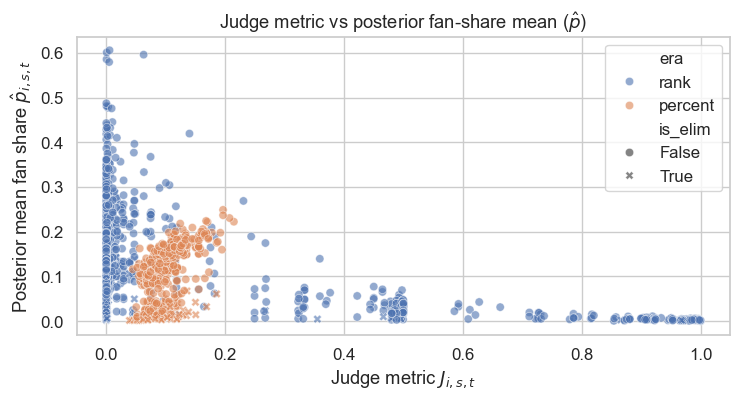

In [198]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# eval_long 是 post + truth 的合并结果（你 notebook 已经构造）
df_scatter = eval_long.copy()
df_scatter["is_elim"] = (df_scatter["celebrity_name"] == df_scatter["elim_true"])

plt.figure(figsize=(7.6,4.2))
sns.scatterplot(
    data=df_scatter,
    x="j_metric", y="p_mean",
    hue="era", style="is_elim",
    alpha=0.6
)
plt.title(r"Judge metric vs posterior fan-share mean ($\hat p$)")
plt.xlabel(r"Judge metric $J_{i,s,t}$")
plt.ylabel(r"Posterior mean fan share $\hat p_{i,s,t}$")
plt.tight_layout()
plt.savefig("fig_J_vs_p_scatter.png", dpi=300, bbox_inches="tight")
plt.show()


/var/folders/1q/v465hb014m30111mh0rv30rh0000gn/T/ipykernel_44988/595306624.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rel = cal.groupby(["era","bin"]).agg(


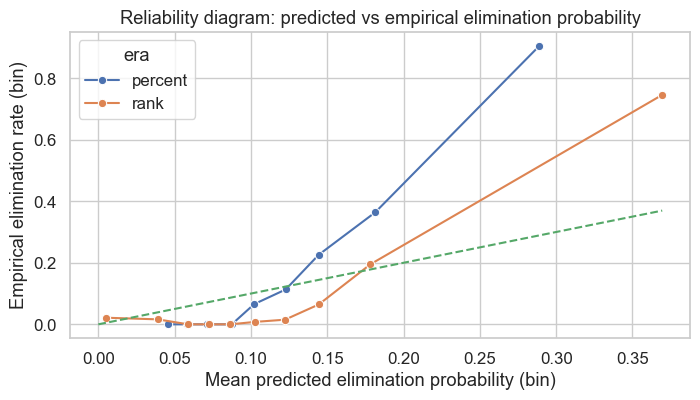

In [199]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def softmin_probs_np(C, tau=0.15):
    x = -C / tau
    x = x - np.max(x)
    p = np.exp(x)
    return p / p.sum()

# 生成长表：每个(week, contestant) 的预测淘汰概率 + 是否真淘汰
rows = []
for (s,w), g in eval_long.groupby(["season","week"]):
    g = g.sort_values("celebrity_name").copy()
    elim_true = g["elim_true"].iloc[0]
    y = (g["celebrity_name"].values == elim_true).astype(int)

    # 三种方法的概率（以 Model(j+p) 为主，其他可同理扩展）
    C = g["j_metric"].to_numpy() + g["p_mean"].to_numpy()
    pr = softmin_probs_np(C, tau=0.15)  # tau 与训练保持一致时更合理

    rows.append(pd.DataFrame({
        "era": g["era"].iloc[0],
        "pr_elim": pr,
        "is_elim": y
    }))

cal = pd.concat(rows, ignore_index=True)

# 分箱做 reliability diagram
cal["bin"] = pd.qcut(cal["pr_elim"], q=10, duplicates="drop")
rel = cal.groupby(["era","bin"]).agg(
    pr_mean=("pr_elim","mean"),
    elim_rate=("is_elim","mean"),
    n=("is_elim","size")
).reset_index()

plt.figure(figsize=(7.2,4.2))
sns.lineplot(data=rel, x="pr_mean", y="elim_rate", hue="era", marker="o")
plt.plot([0, rel["pr_mean"].max()], [0, rel["pr_mean"].max()], linestyle="--")
plt.title("Reliability diagram: predicted vs empirical elimination probability")
plt.xlabel("Mean predicted elimination probability (bin)")
plt.ylabel("Empirical elimination rate (bin)")
plt.tight_layout()
plt.savefig("fig_calibration_reliability.png", dpi=300, bbox_inches="tight")
plt.show()


In [200]:
import numpy as np
import pandas as pd

# 你 notebook 已有 softmin 权重计算，这里写成函数复用
def softmin_logprob_elim(cost, elim_pos, tau=0.15):
    """
    cost: (B, n)  = J + p_draw
    return: log P(elim_pos | cost) for each draw, shape (B,)
    """
    z = -cost / tau
    z = z - z.max(axis=1, keepdims=True)         # stabilize
    log_denom = np.log(np.exp(z).sum(axis=1))
    return z[:, elim_pos] - log_denom

def compute_week_pcp(panel, pooled_fit, season, week, *, kappa=30.0, B=2500, tau_like=0.15, seed=123):
    """
    返回：pcp（posterior consistency probability）+ 一些诊断统计（ESS, alive size）
    """
    rng = np.random.default_rng(seed)

    # 取该周 alive set，并且带 q_hat（你 notebook 里 pooled_q_for_week 会做）
    g = pooled_q_for_week(panel, pooled_fit, season=season, week=week).copy()
    alive = g.copy()
    n = alive.shape[0]
    if n <= 1:
        return None

    # 必须是单淘汰周才有 i*
    if alive["elim_this_week_end"].sum() != 1:
        return None

    elim_name = alive.loc[alive["elim_this_week_end"], "celebrity_name"].iloc[0]
    names = alive["celebrity_name"].to_numpy()
    elim_pos = int(np.where(names == elim_name)[0][0])

    # Dirichlet prior
    q = alive["q_hat"].to_numpy()
    alpha = kappa * q

    # posterior draws via importance sampling
    p_samps = rng.dirichlet(alpha, size=B)  # (B,n)

    j = alive["j_metric"].to_numpy()
    cost = j[None, :] + p_samps             # (B,n)

    logp_elim = softmin_logprob_elim(cost, elim_pos, tau=tau_like)
    w = np.exp(logp_elim - logp_elim.max())
    w = w / w.sum()

    # PCP: under each draw, predict elim by argmin(J+p_draw)
    pred_pos = np.argmin(cost, axis=1)      # (B,)
    hit = (pred_pos == elim_pos).astype(float)
    pcp = float((w * hit).sum())

    # optional diagnostics: ESS (effective sample size)
    ess = float(1.0 / np.sum(w**2))

    return {
        "season": int(season),
        "week": int(week),
        "era": alive["era"].iloc[0],
        "n_alive": int(n),
        "elim_true": elim_name,
        "pcp": pcp,
        "ess": ess,
        "kappa": float(kappa),
        "B": int(B),
        "tau_like": float(tau_like),
    }

# 批量计算（用训练/评估周集合）
rows = []
for s, wk in train_weeks[["season", "week"]].values.tolist():
    out = compute_week_pcp(panel, pooled_fit, int(s), int(wk),
                           kappa=30.0, B=2500, tau_like=0.15, seed=SEED + int(s)*1000 + int(wk))
    if out is not None:
        rows.append(out)

pcp_week = pd.DataFrame(rows)
pcp_week.head(), pcp_week.shape


(   season  week   era  n_alive          elim_true       pcp          ess  \
 0       1     2  rank        6      Trista Sutter  0.938853  2427.484775   
 1       1     3  rank        5  Evander Holyfield  0.939916  2364.509233   
 2       1     4  rank        4      Rachel Hunter  0.923932  2431.561788   
 3       2     1  rank       10        Kenny Mayne  0.886313  2466.062801   
 4       2     2  rank        9       Tatum O'Neal  0.680218  2457.700031   
 
    kappa     B  tau_like  
 0   30.0  2500      0.15  
 1   30.0  2500      0.15  
 2   30.0  2500      0.15  
 3   30.0  2500      0.15  
 4   30.0  2500      0.15  ,
 (218, 10))

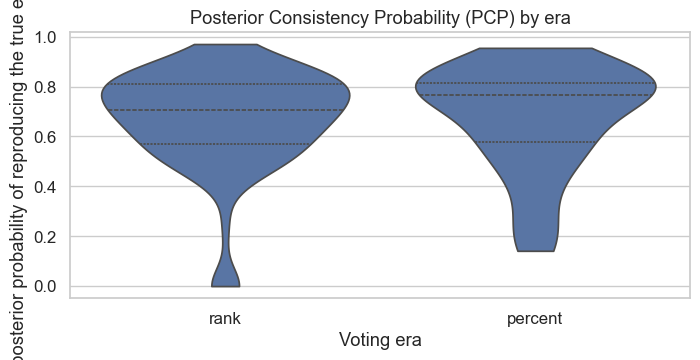

In [201]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7.2, 3.8))
sns.violinplot(data=pcp_week, x="era", y="pcp", inner="quartile", cut=0)
plt.title("Posterior Consistency Probability (PCP) by era")
plt.xlabel("Voting era")
plt.ylabel("PCP (posterior probability of reproducing the true eliminatee)")
plt.tight_layout()
plt.savefig("fig_pcp_by_era.png", dpi=300, bbox_inches="tight")
plt.show()


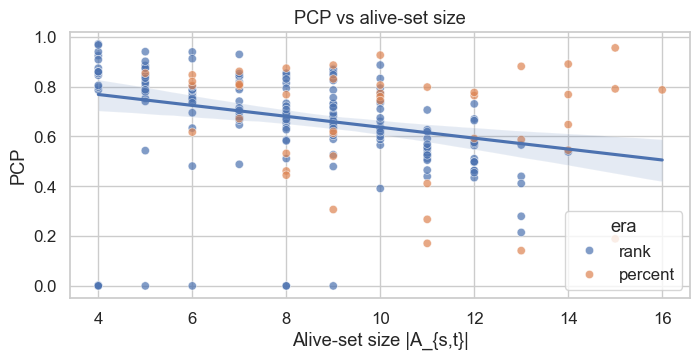

In [202]:
plt.figure(figsize=(7.2, 3.8))
sns.scatterplot(data=pcp_week, x="n_alive", y="pcp", hue="era", alpha=0.7)
sns.regplot(data=pcp_week, x="n_alive", y="pcp", scatter=False)  # overall trend
plt.title("PCP vs alive-set size")
plt.xlabel("Alive-set size |A_{s,t}|")
plt.ylabel("PCP")
plt.tight_layout()
plt.savefig("fig_pcp_vs_alive.png", dpi=300, bbox_inches="tight")
plt.show()


In [203]:
pcp_week.sort_values("pcp").head(10)


,season,week,era,n_alive,elim_true,pcp,ess,kappa,B,tau_like
156,23,10,rank,5,Terra Jole,0.000000,2378.308325,30.0,2500,0.15
115,17,5,rank,9,Christina Milian,0.000000,2449.850907,30.0,2500,0.15
161,24,6,rank,8,Heather Morris,0.000000,2487.875372,30.0,2500,0.15
99,14,9,rank,4,Maria Menounos,0.000000,2442.218986,30.0,2500,0.15
163,24,9,rank,4,Simone Biles,0.000000,2444.782863,30.0,2500,0.15
103,15,6,rank,8,Sabrina Bryan,0.000000,2458.384172,30.0,2500,0.15
149,22,8,rank,6,Jodie Sweetin,0.000000,2416.955450,30.0,2500,0.15
140,20,9,rank,4,Nastia Liukin,0.002472,2419.855369,30.0,2500,0.15
199,32,2,percent,13,Jamie Lynn Spears,0.141506,2472.834953,30.0,2500,0.15
212,34,4,percent,11,Hilaria Baldwin,0.170724,2479.011806,30.0,2500,0.15
